In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from fismi import ismiReplication as fismi
from fismi import utils
from fismi import figures
from fismi import maths
import statsmodels.api as sm
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf

In [2]:
### Import data / Settings
niv = '2'
lag = 12

# Unchained other items 
dfICP = pd.read_parquet(f"input/USItemsLvl{niv}.parquet")
dfW = pd.read_parquet(f"input/USnormedWeightsLvl{niv}.parquet") 

# We compute monthly inflation rates
headlineYoy = (np.log(dfICP["Personal consumption expenditures"]).diff(12))[lag:]
dI = (np.log(dfICP).diff(lag))[lag:]
dICP = dI["Personal consumption expenditures"].to_frame()           
dI = dI.drop("Personal consumption expenditures",axis=1)

# Drop series
if niv=='4':
    colToDrop = ["Internet access (72)","Video and audio streaming and rental"]
    dI = dI.loc[:, ~dI.columns.isin(colToDrop)]
    dfW = dfW.loc[:, ~dfW.columns.isin(colToDrop)]

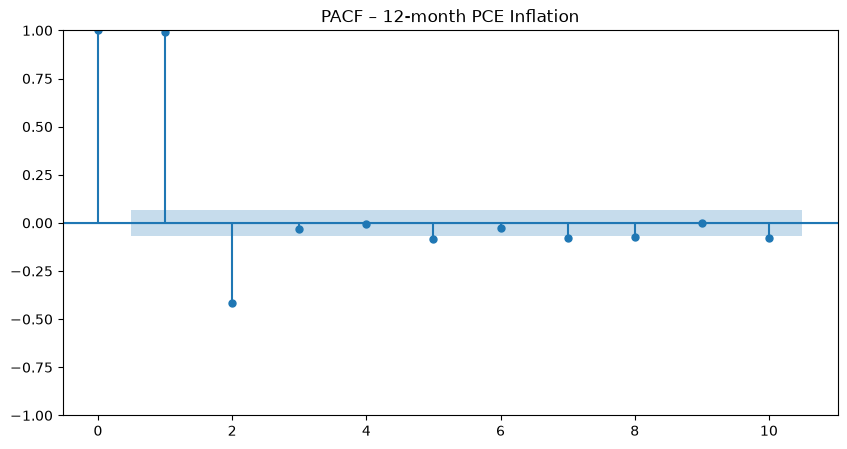

In [3]:
# Série propre
x = dICP.dropna()

# Valeurs numériques
pacf_values = pacf(x, nlags=10)

# Graphique : on passe InflTot, PAS pacf_values
fig, ax = plt.subplots(figsize=(10, 5))

plot_pacf(
    x,
    lags=10,
    method="ywm",
    ax=ax
)

ax.axhline(0, linewidth=0.8)
ax.set_title(f"PACF – {lag}-month PCE Inflation")

plt.show()

In [4]:
# Initial parameters ; Headline
pi = dICP.iloc[:,0].values

F = 0.9
mu = pi.mean()            
rho_bar = 0.5
D = pi.std()              
B = 0.2

X0 = [mu, rho_bar, F, D, B]
M = 1
mu, rho_bar, F, H, Q = maths.get_parameters(X0, M)

print(f"Average monthly inflation : {mu}")
print(f"Long-run persistence : {rho_bar}")
print(f"AR(1) state coefficient (inertial persistence) : {F}")
print(f"Measurement error variance : {H}")
print(f"Variance of the state innovations : {Q}")

Average monthly inflation : 0.03208714412701736
Long-run persistence : 0.5
AR(1) state coefficient (inertial persistence) : 0.9
Measurement error variance : 0.0005156385986125032
Variance of the state innovations : 0.04000000000000001


In [5]:
# Optimise...
res = maths.optNegLogLike(X0, pi)

In [6]:
# Get parameters...
print("Optimisation successful...")
_, _, F, H, Q = maths.get_parameters(res.x, M)
print(f"AR(1) state coefficient (inertial persistence) : {F}")
print(f"Measurement error variance : {H}")
print(f"Variance of the state innovations : {Q}")

Optimisation successful...
AR(1) state coefficient (inertial persistence) : 0.999
Measurement error variance : 5.264666982218048e-06
Variance of the state innovations : 0.00020563040775104608


In [7]:
# Filter...
results = maths.kalman_filter_inflation(res.x, pi, return_loglik=False)

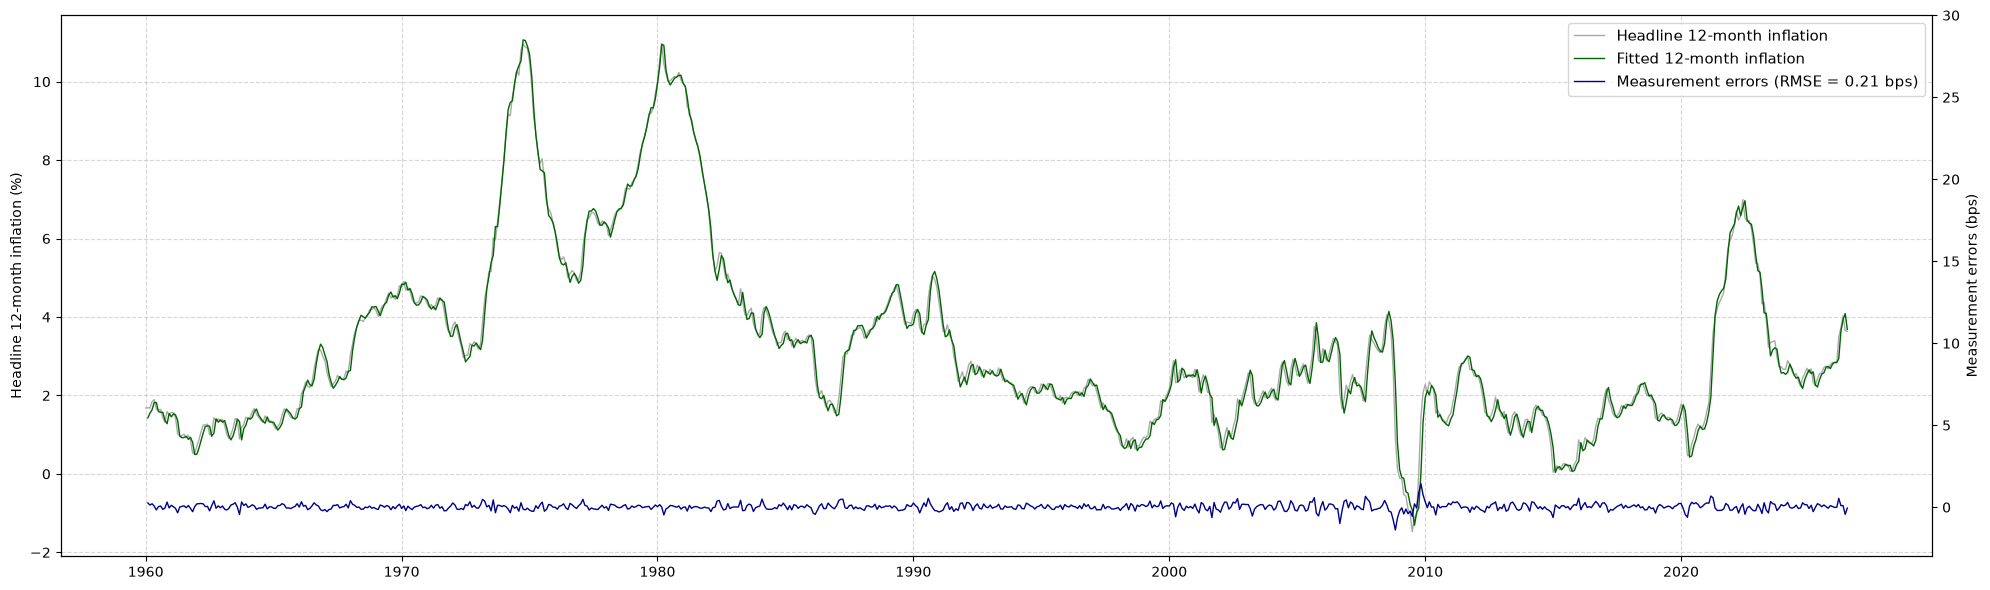

In [8]:
# Inflation versus predicted
fitted = results["FittedY"]
pi = results["Y"]
MSE = pi-fitted
rmse = utils.rmse(pi,fitted)
xAxis = dI.index

fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(
    xAxis,
    pi*100,
    label=f"Headline {lag}-month inflation",
    color="darkgrey",
    linewidth=1
)

ax.grid(True, linestyle="--", alpha=0.5)

ax.plot(
    xAxis,
    fitted*100,
    label=f"Fitted {lag}-month inflation",
    color="darkgreen",
    linewidth=1
)
ax.set_ylabel(f"Headline {lag}-month inflation (%)")

# Résidus...
# --- Right axis (MSE) ---
ax2 = ax.twinx()

ax2.plot(
    xAxis,
    MSE*100,
    label=f"Measurement errors (RMSE = {rmse*100:.2f} bps)",
    color="darkblue",
    linewidth=1
)

ax2.set_ylabel("Measurement errors (bps)")
ax2.tick_params(axis="y")
ax2.set_ylim(-3, 30)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=11)
plt.tight_layout()
plt.show()


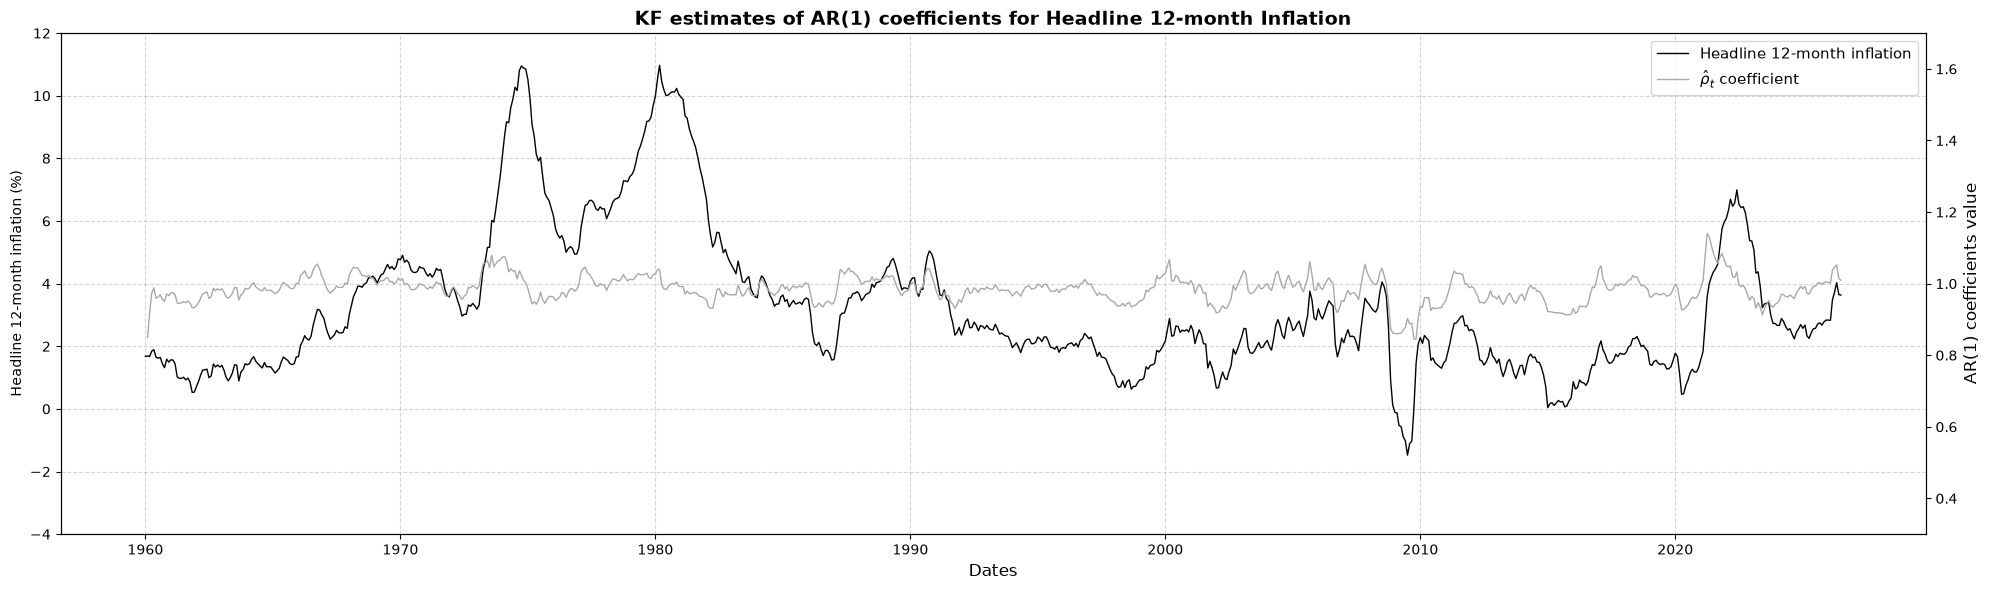

In [9]:
# Rolling persistance coefficient since 1959 against headline PCE
Rho = results["Rho"]
fig, ax1 = plt.subplots(figsize=(20, 6))

# --- Left axis (HICP inflation - 12-month) ---
ax1.plot(
    xAxis,
    headlineYoy*100,
    label=f"Headline {lag}-month inflation",
    color="black",
    linewidth=1
)

ax1.set_xlabel("Dates", fontsize=12)
ax1.set_ylabel(f"Headline {lag}-month inflation (%)")
ax1.set_ylim(-4, 12)
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Right axis (AR coefficients) ---
ax2 = ax1.twinx()

ax2.plot(
    xAxis,
    Rho,
    label=r'$\hat \rho_t$ coefficient',
    color="darkgrey",
    linewidth=1
)

ax2.set_ylabel("AR(1) coefficients value", fontsize=12)
ax2.set_ylim(0.3, 1.7)
ax2.tick_params(axis="y")

# --- Title, legend ---
plt.title(f"KF estimates of AR(1) coefficients for Headline {lag}-month Inflation", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=11)

plt.tight_layout()
plt.show()

In [10]:
# We compute the persistance of PCE components
allResults = {}
allResults["HeadlinePce"] = results

for i in range(len(dI.columns)):
    pi = dI.iloc[:,i].values
    colName = dI.iloc[:,i].name
    
    # Get initial parameters...
    print(f"Component '{colName}' : initial parameters...")
    
    F = 0.9
    mu = pi.mean()            
    rho_bar = 0.5
    D = pi.std()              
    B = 0.2

    X0 = [mu, rho_bar, F, D, B]
    mu, rho_bar, F, H, Q = maths.get_parameters(X0, 1)
    
    # Estimate by LogLikelihood..
    res = maths.optNegLogLike(X0, pi)
    
    # Store results...
    results = maths.kalman_filter_inflation(res.x, pi, return_loglik=False)
    mu, rho_bar, F, H, Q = maths.get_parameters(res.x, 1)
    print(f"Average monthly inflation : {mu:.3f}")
    print(f"Long-run persistence : {rho_bar:.3f}")
    print(f"AR(1) state coefficient (inertial persistence) : {F:.3f}")
    print(f"Measurement error variance : {H:.3f}")
    print(f"Variance of the state innovations : {Q:.3f}")
    print("")
    
    allResults[colName] = results


Component 'Clothing and footwear' : initial parameters...
Average monthly inflation : 0.011
Long-run persistence : 0.500
AR(1) state coefficient (inertial persistence) : 0.999
Measurement error variance : 0.000
Variance of the state innovations : 0.000

Component 'Financial services and insurance' : initial parameters...
Average monthly inflation : 0.041
Long-run persistence : 0.500
AR(1) state coefficient (inertial persistence) : 0.999
Measurement error variance : 0.000
Variance of the state innovations : 0.001

Component 'Food and beverages purchased for off-premises consumption' : initial parameters...
Average monthly inflation : 0.032
Long-run persistence : 0.500
AR(1) state coefficient (inertial persistence) : 0.971
Measurement error variance : 0.000
Variance of the state innovations : 0.005

Component 'Food services and accommodations' : initial parameters...
Average monthly inflation : 0.041
Long-run persistence : 0.500
AR(1) state coefficient (inertial persistence) : 0.999
Meas

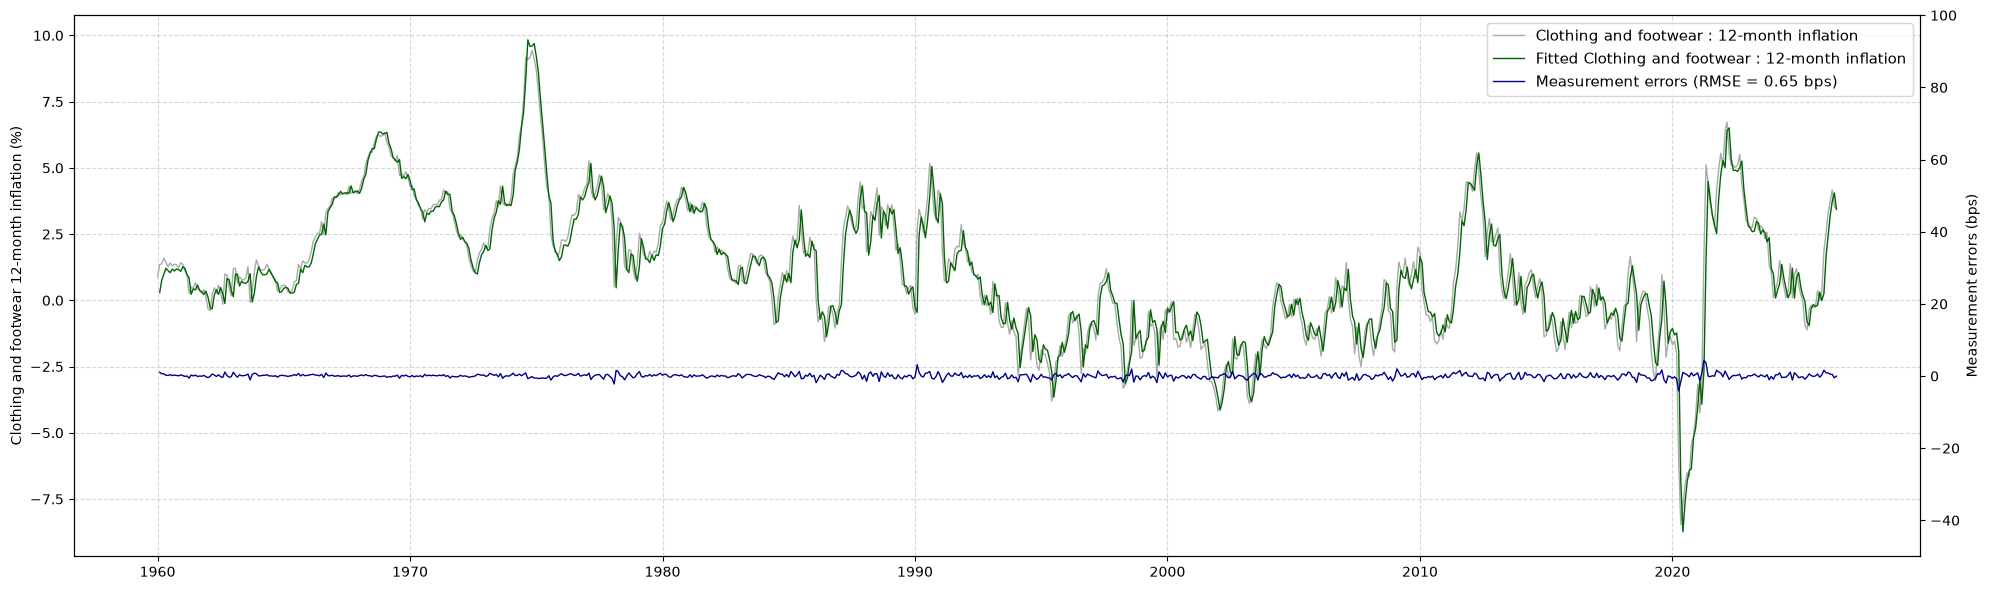

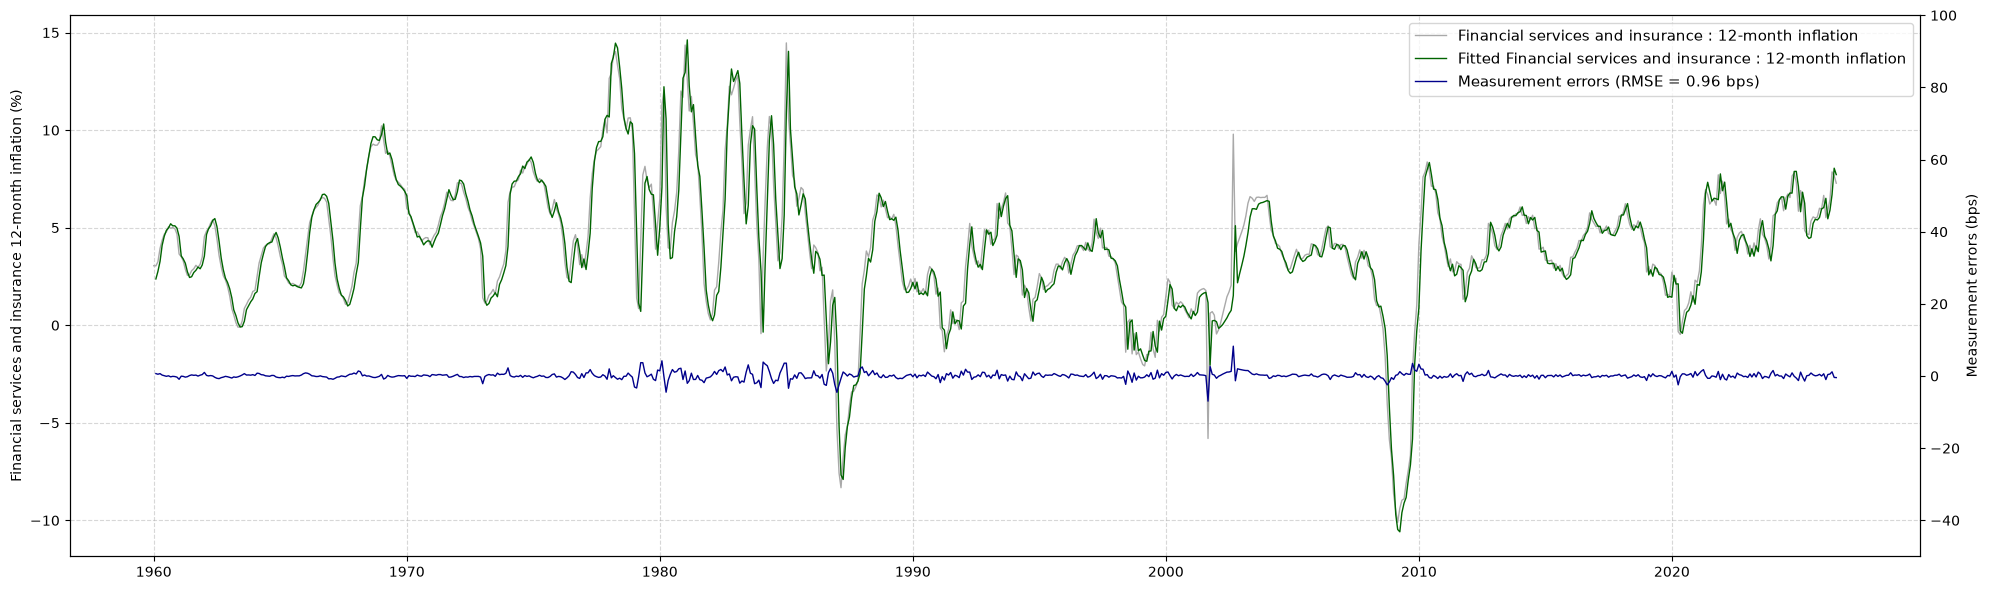

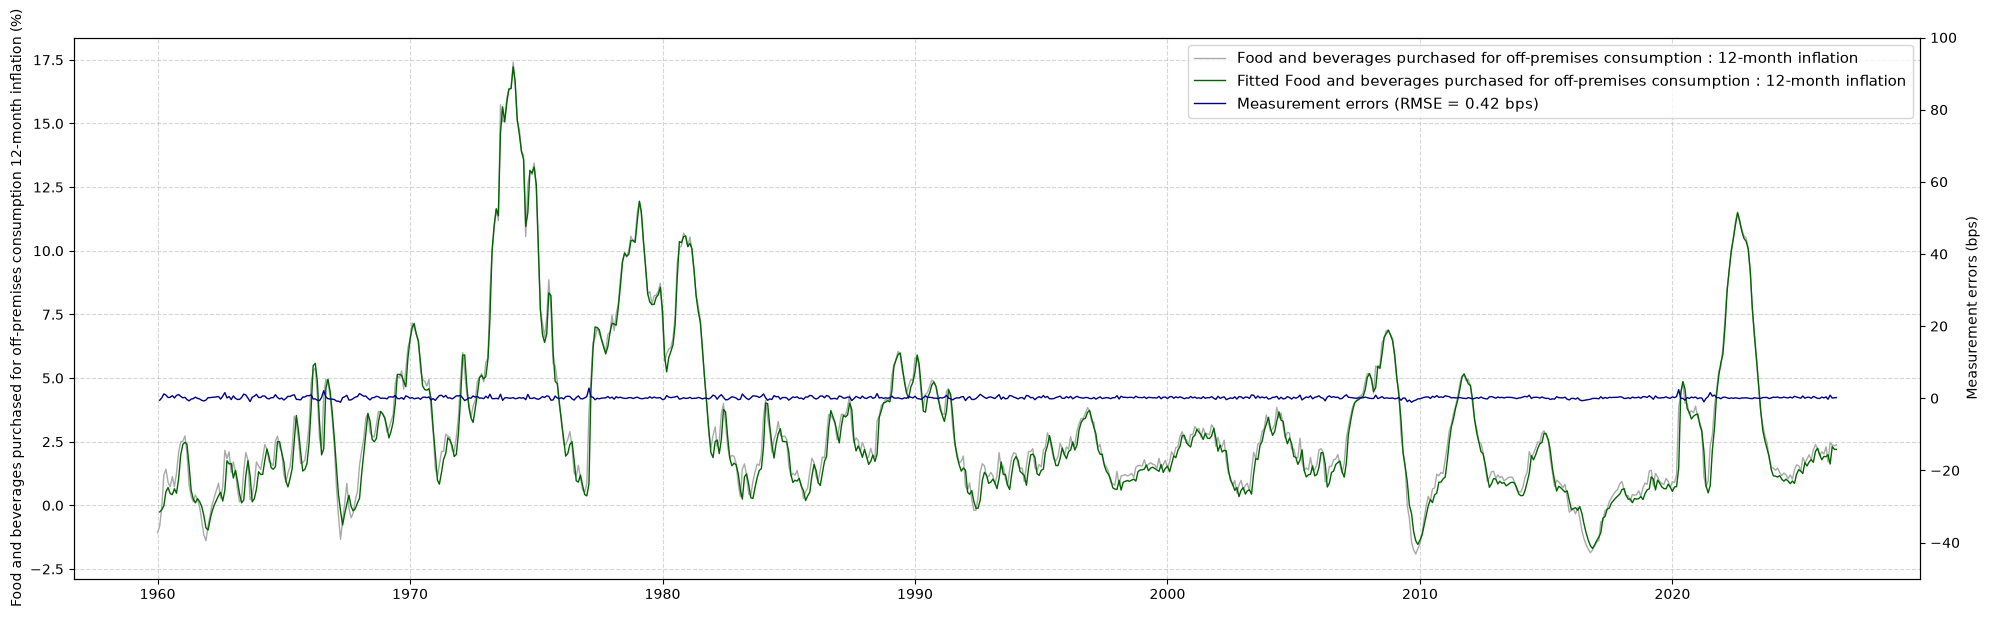

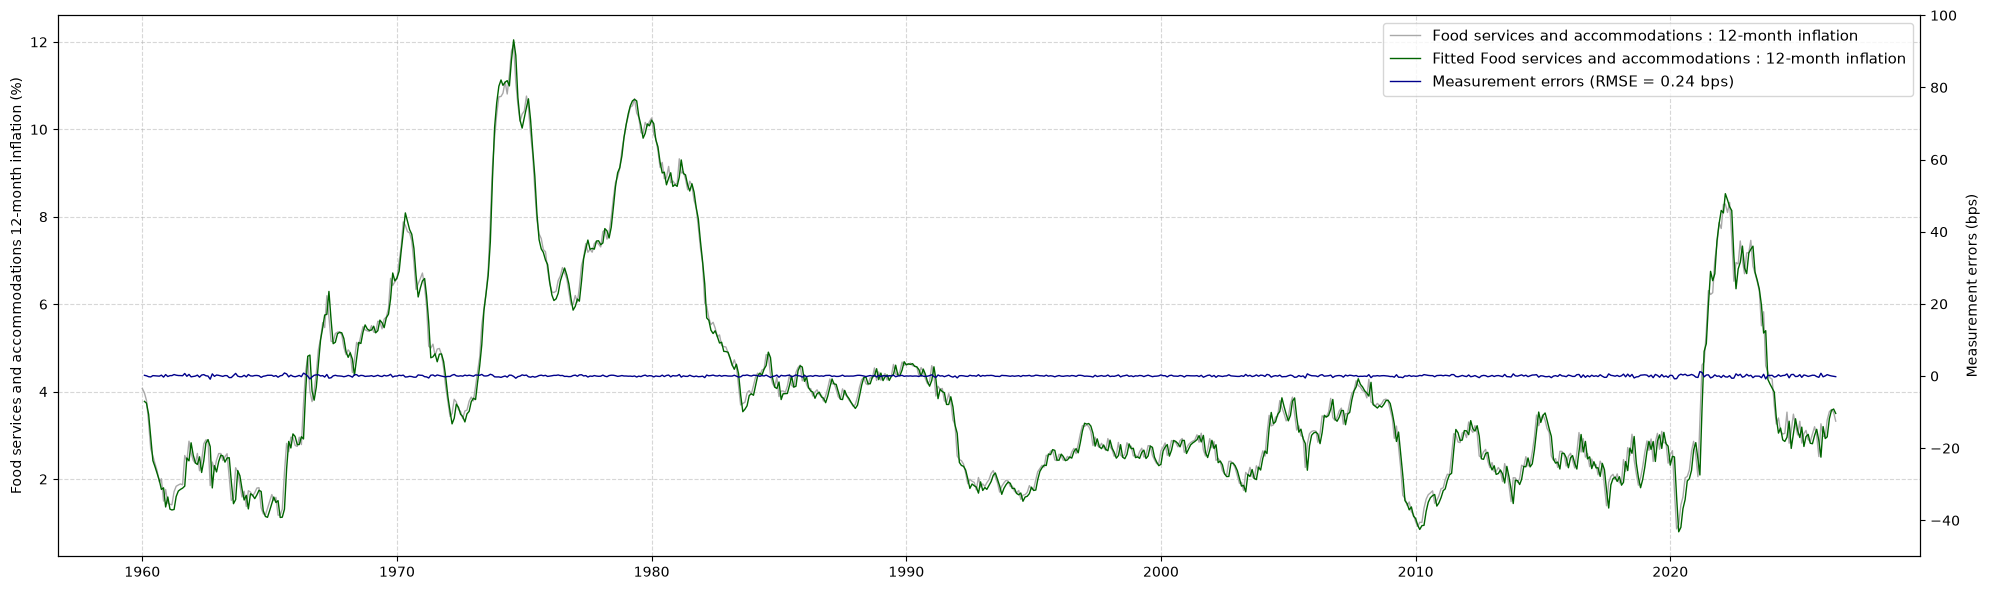

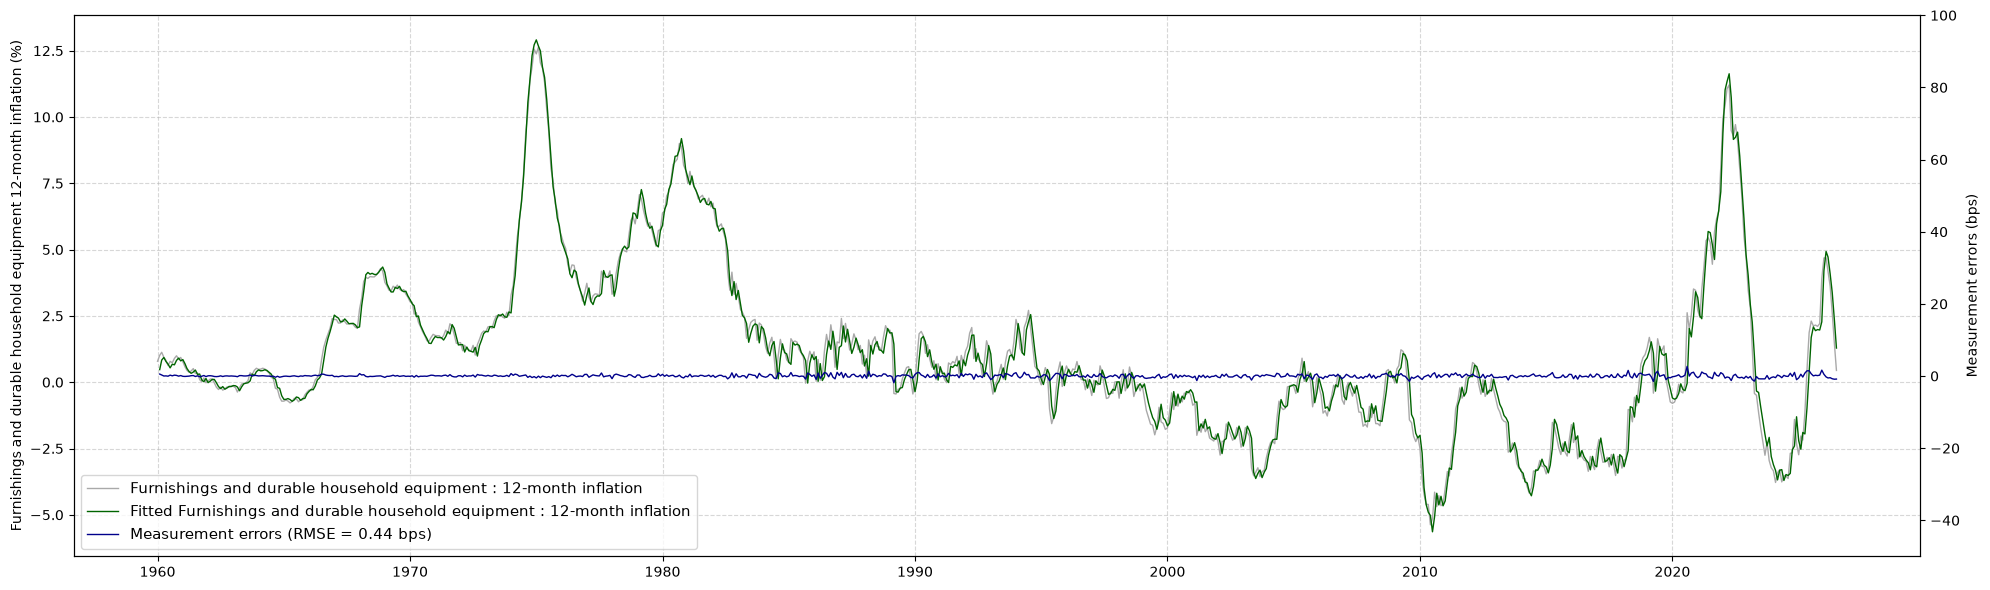

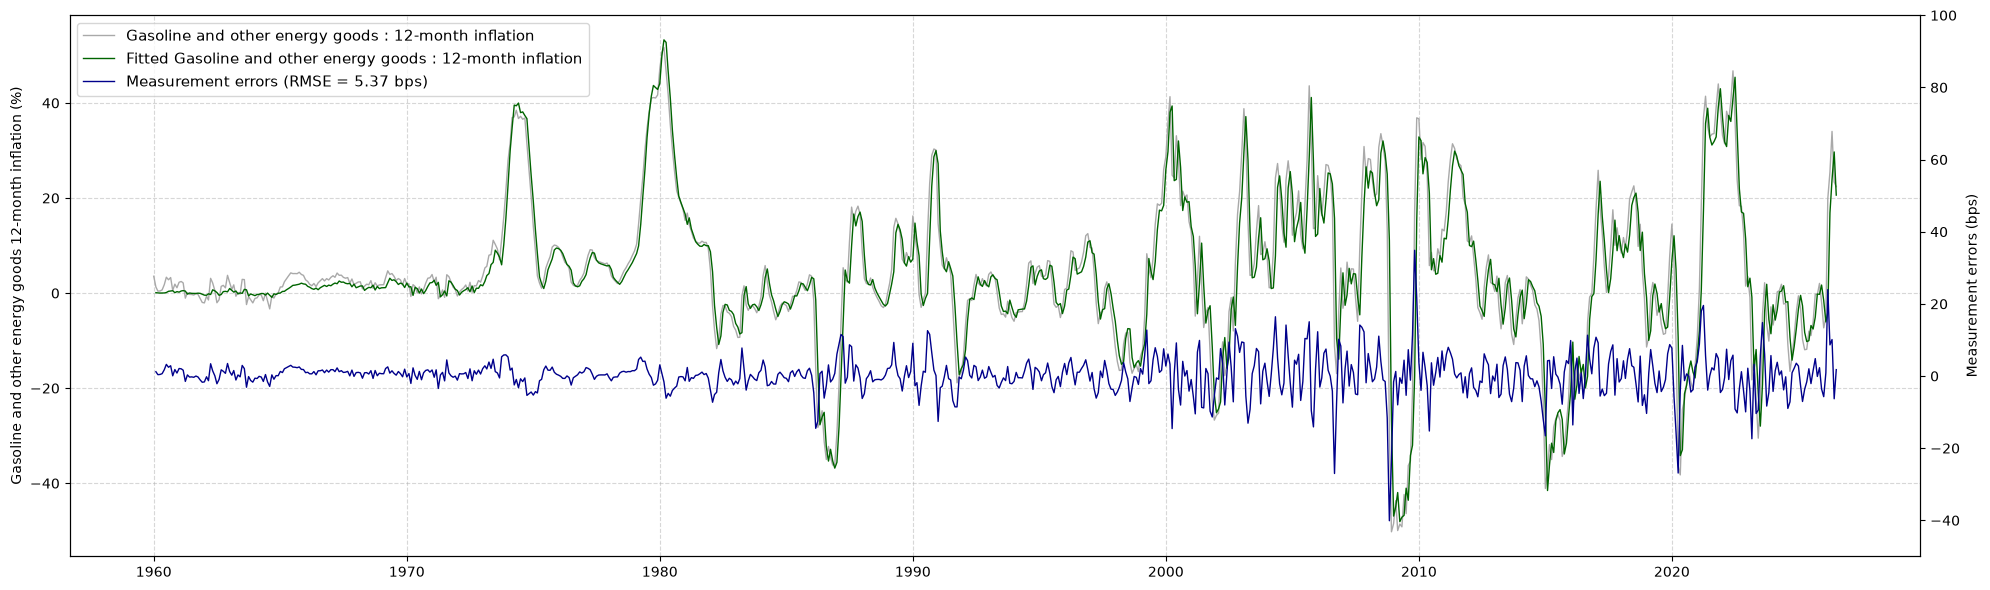

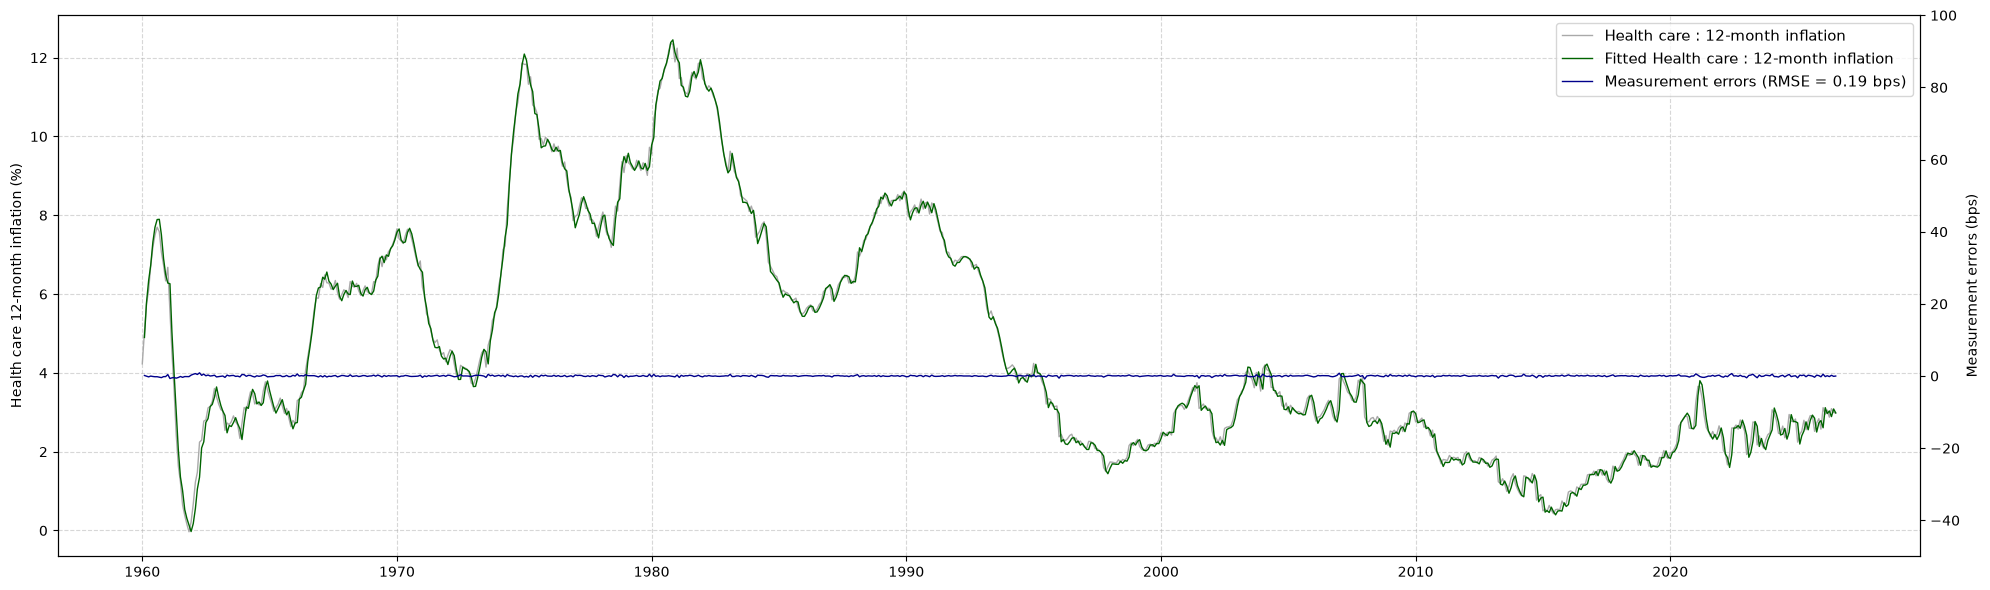

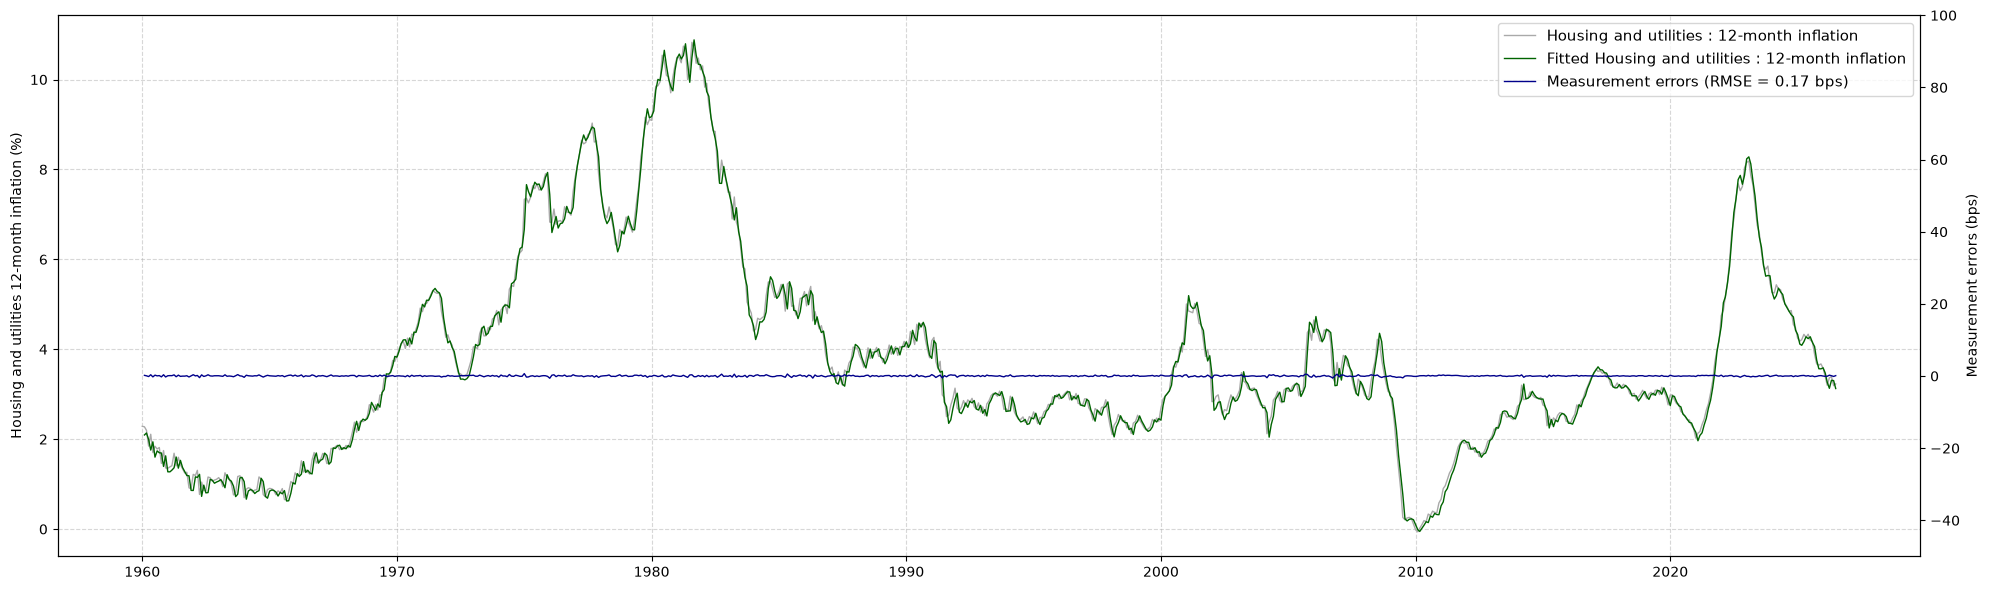

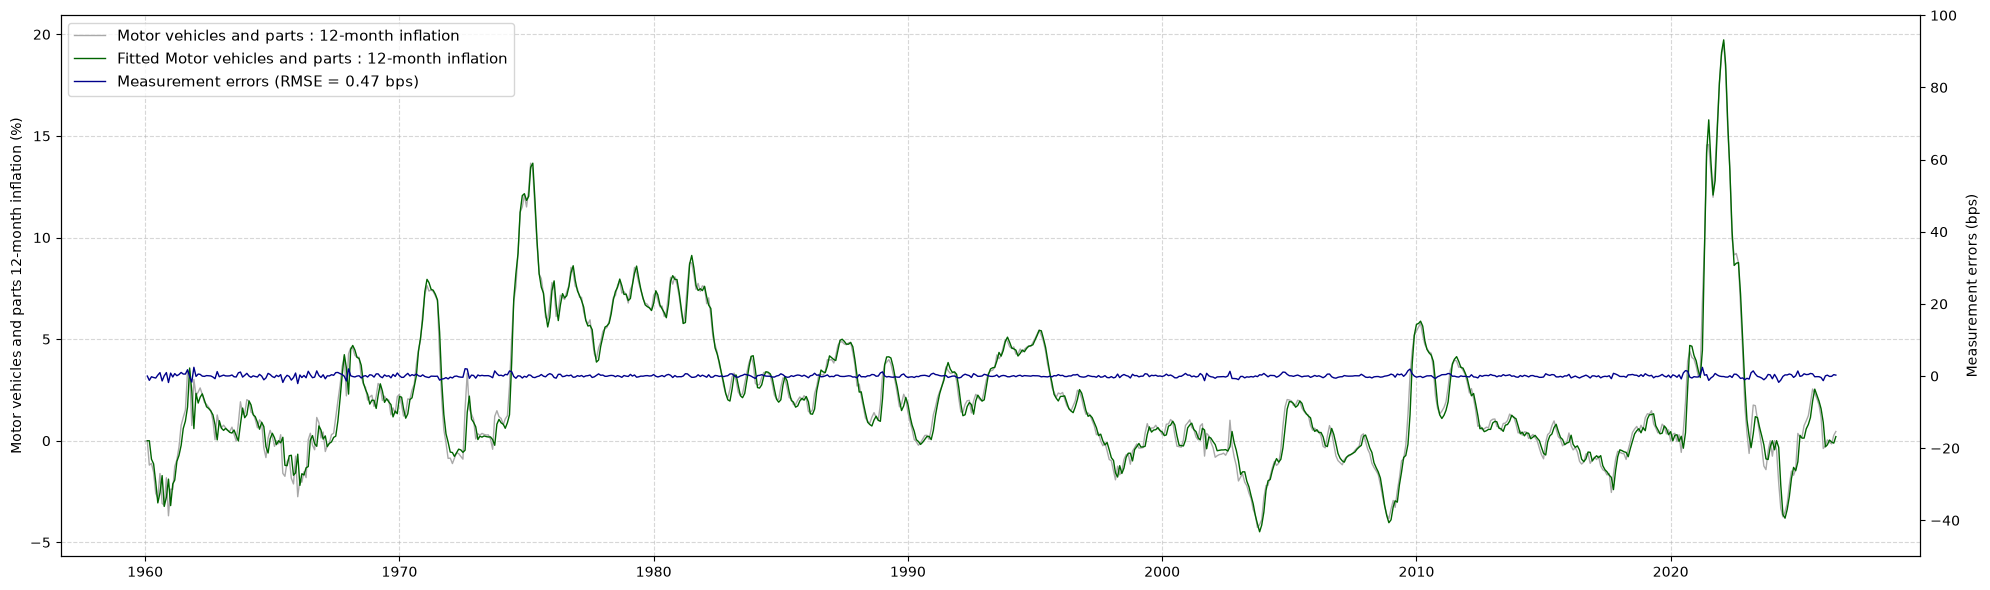

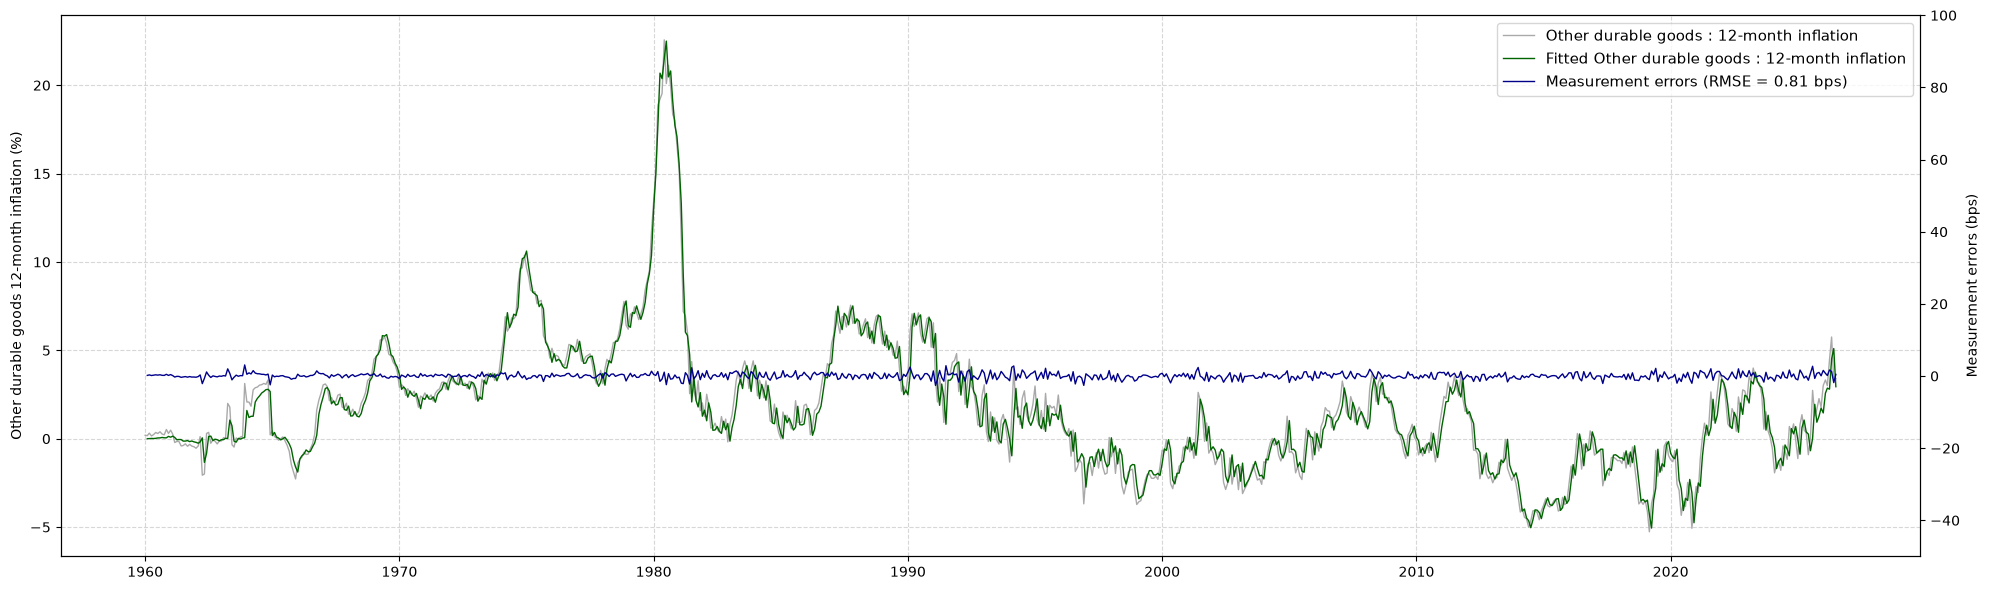

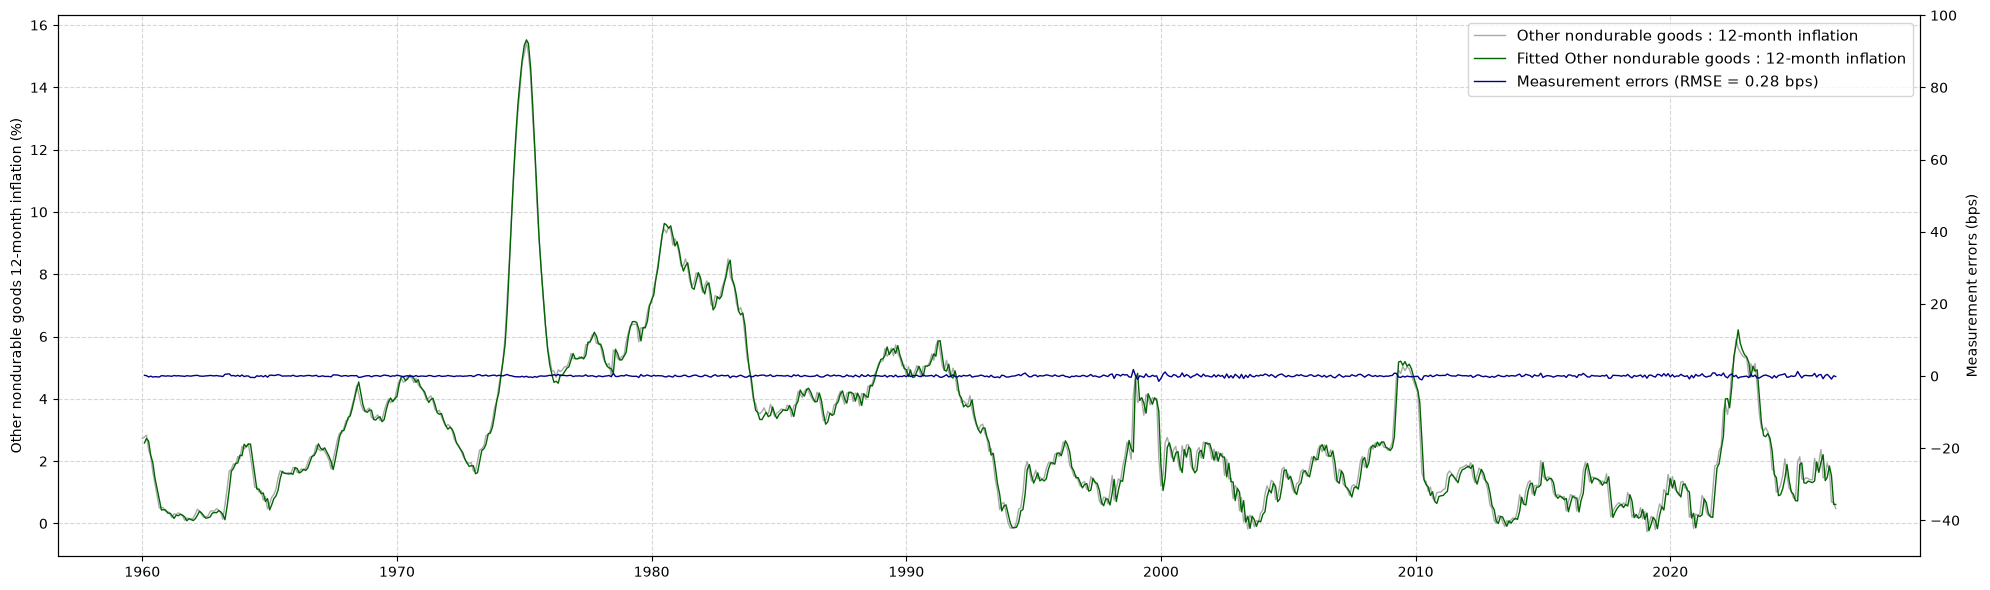

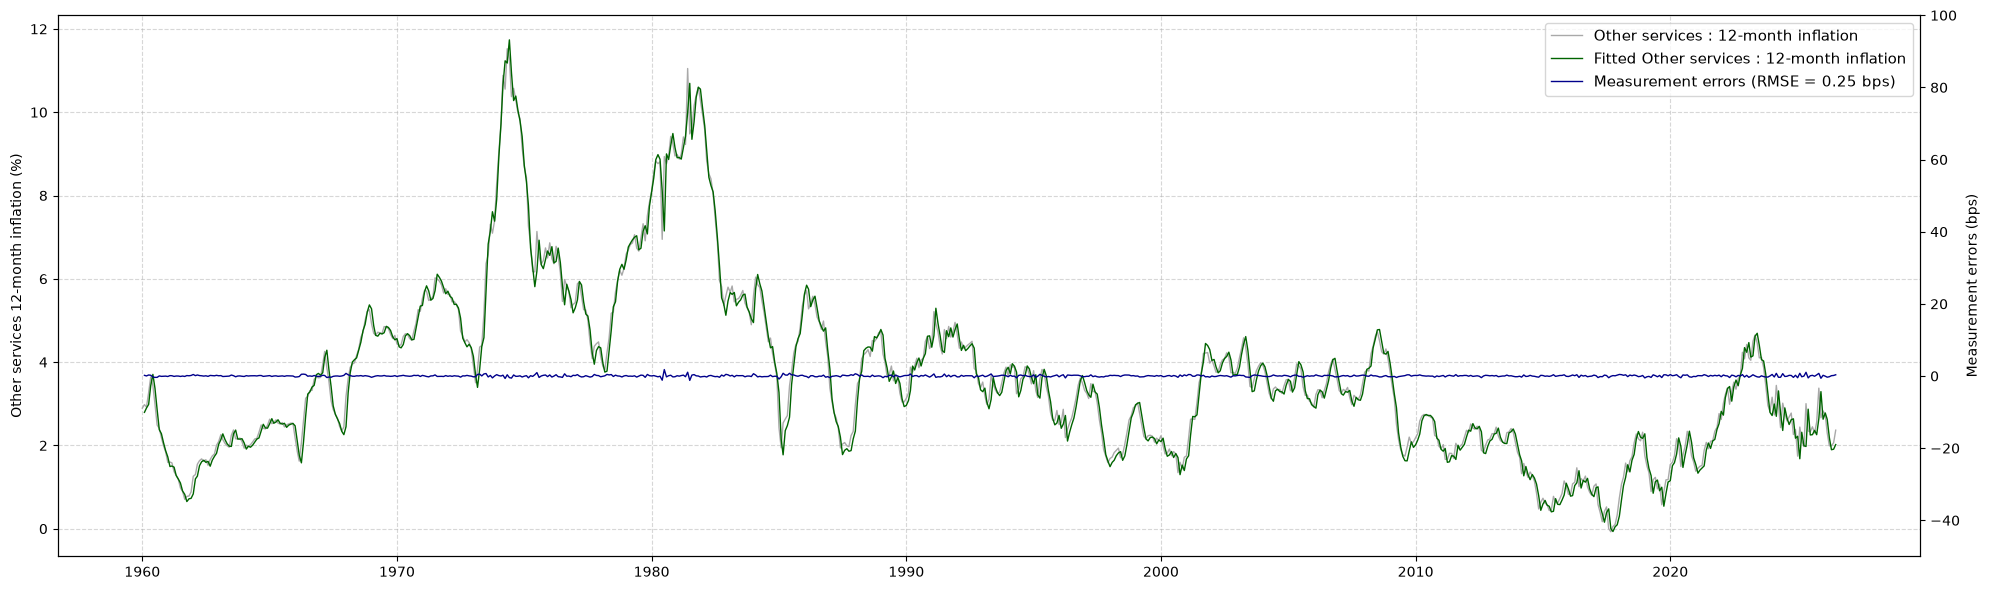

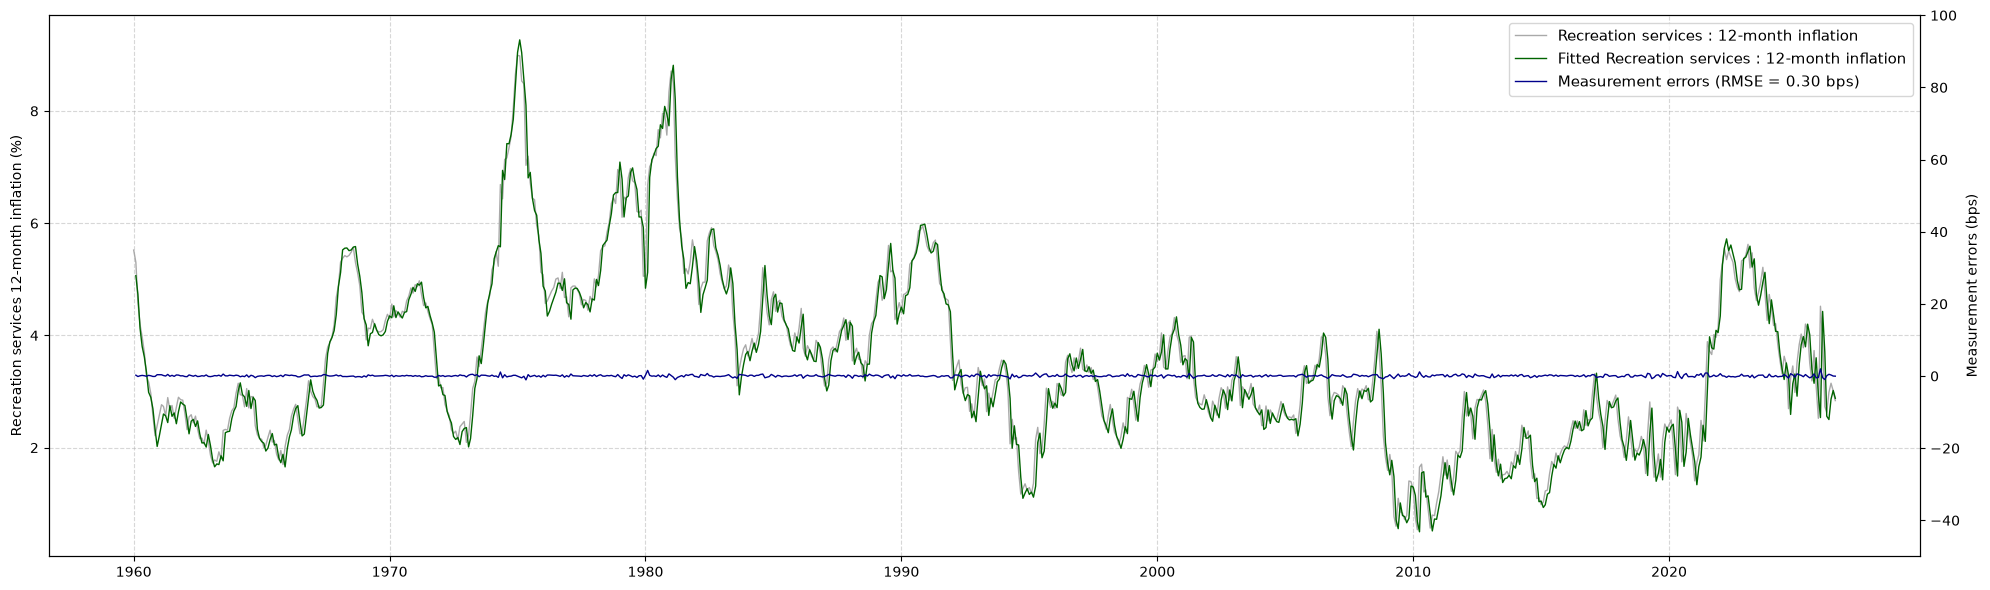

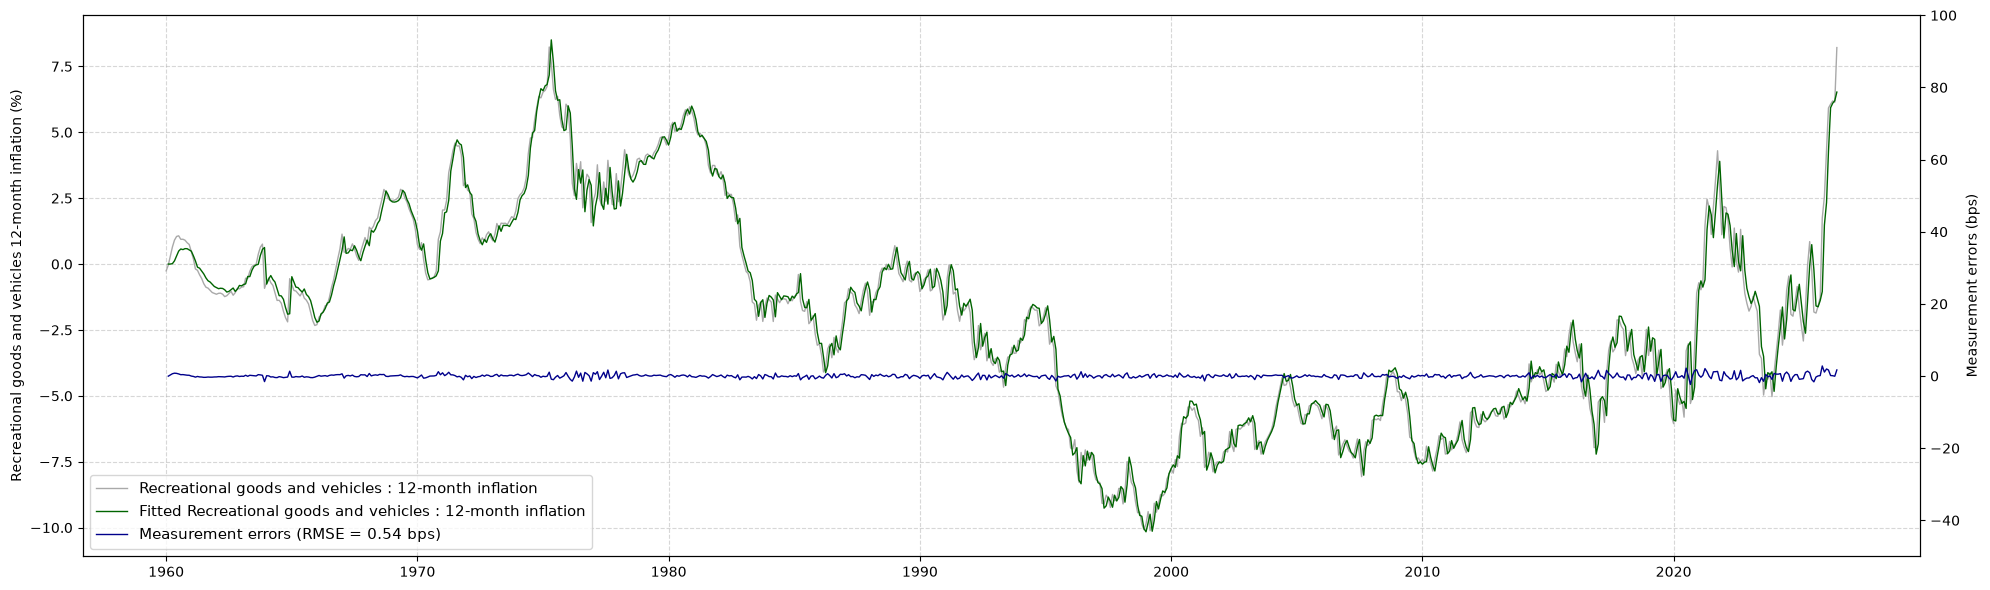

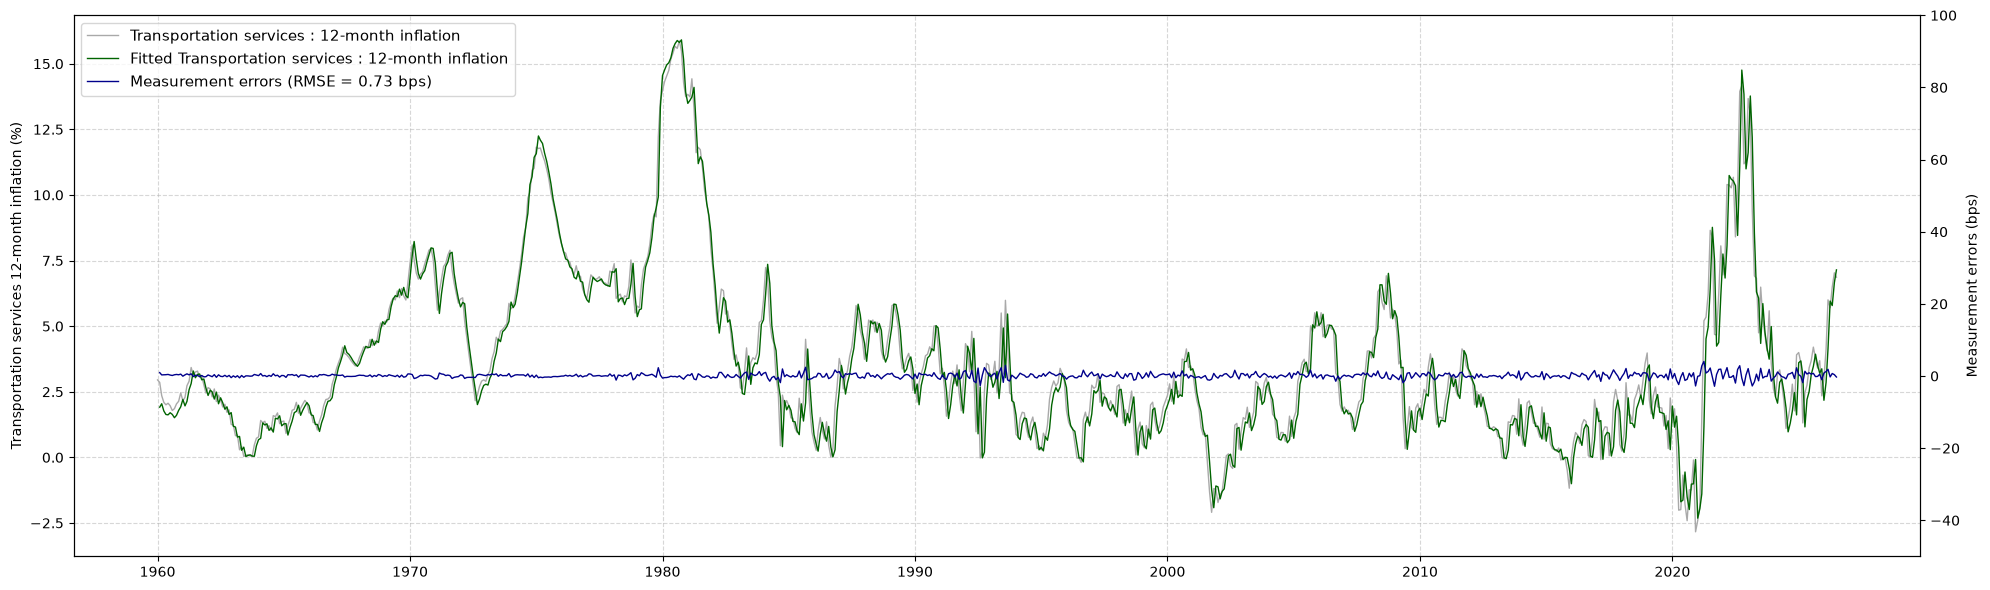

In [11]:
# Charts...
# Inflation by components versus predicted
xAxis = dI.index

for col in dI.columns:
    fitted =  allResults[col]["FittedY"]
    pi = allResults[col]["Y"]
    MSE = pi-fitted
    rmse = utils.rmse(pi,fitted)

    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(
        xAxis,
        pi*100,
        label=f"{col} : {lag}-month inflation",
        color="darkgrey",
        linewidth=1
    )

    ax.grid(True, linestyle="--", alpha=0.5)

    ax.plot(
        xAxis,
        fitted*100,
        label=f"Fitted {col} : {lag}-month inflation",
        color="darkgreen",
        linewidth=1
    )
    ax.set_ylabel(f"{col} {lag}-month inflation (%)")

    # Résidus...
    # --- Right axis (MSE) ---
    ax2 = ax.twinx()

    ax2.plot(
        xAxis,
        MSE*100,
        label=f"Measurement errors (RMSE = {rmse*100:.2f} bps)",
        color="darkblue",
        linewidth=1
    )
    
    ax2.set_ylabel("Measurement errors (bps)")
    ax2.tick_params(axis="y")
    ax2.set_ylim(-50, 100)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=11)
    plt.tight_layout()
    plt.show()


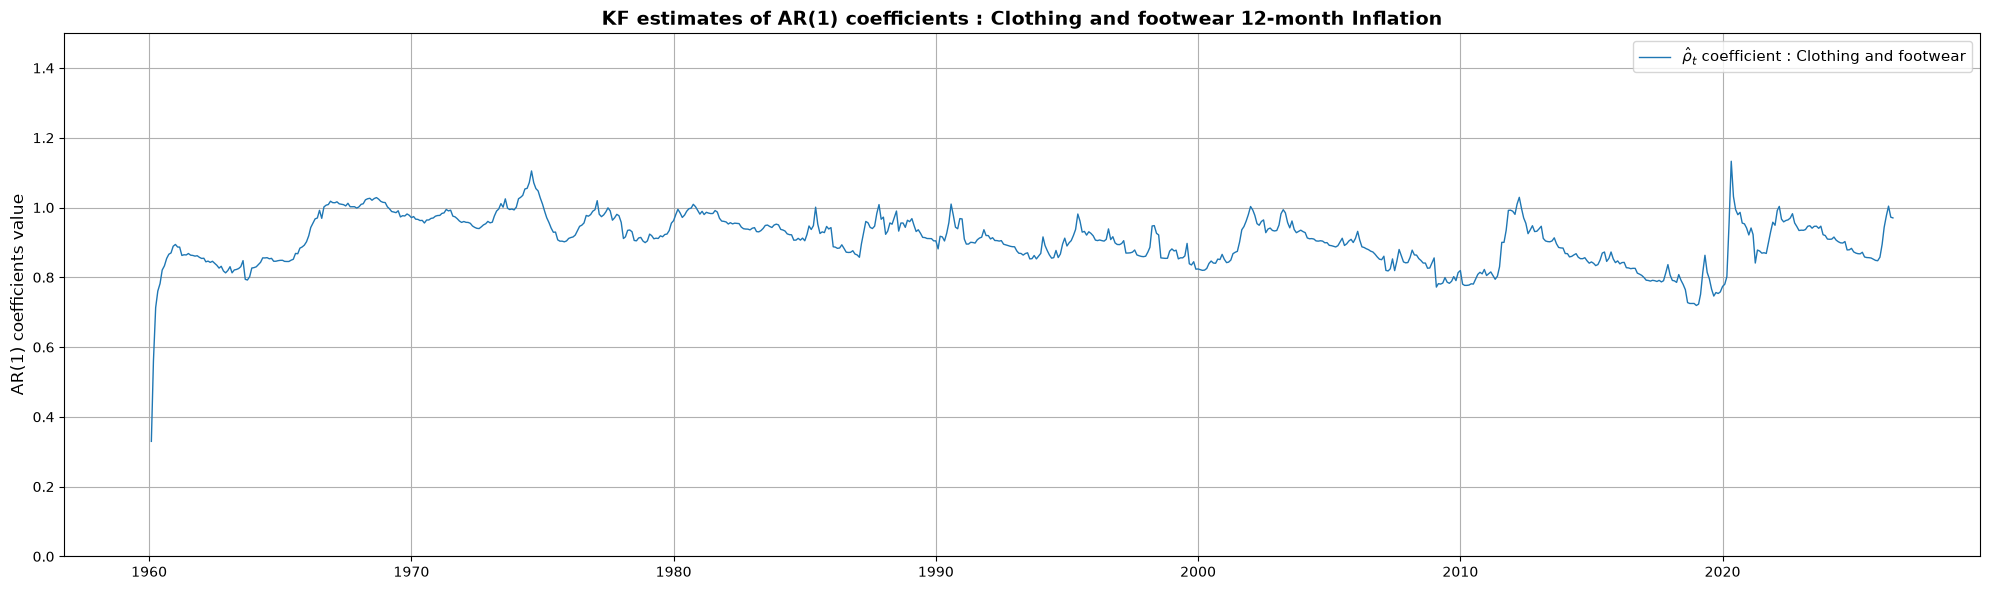

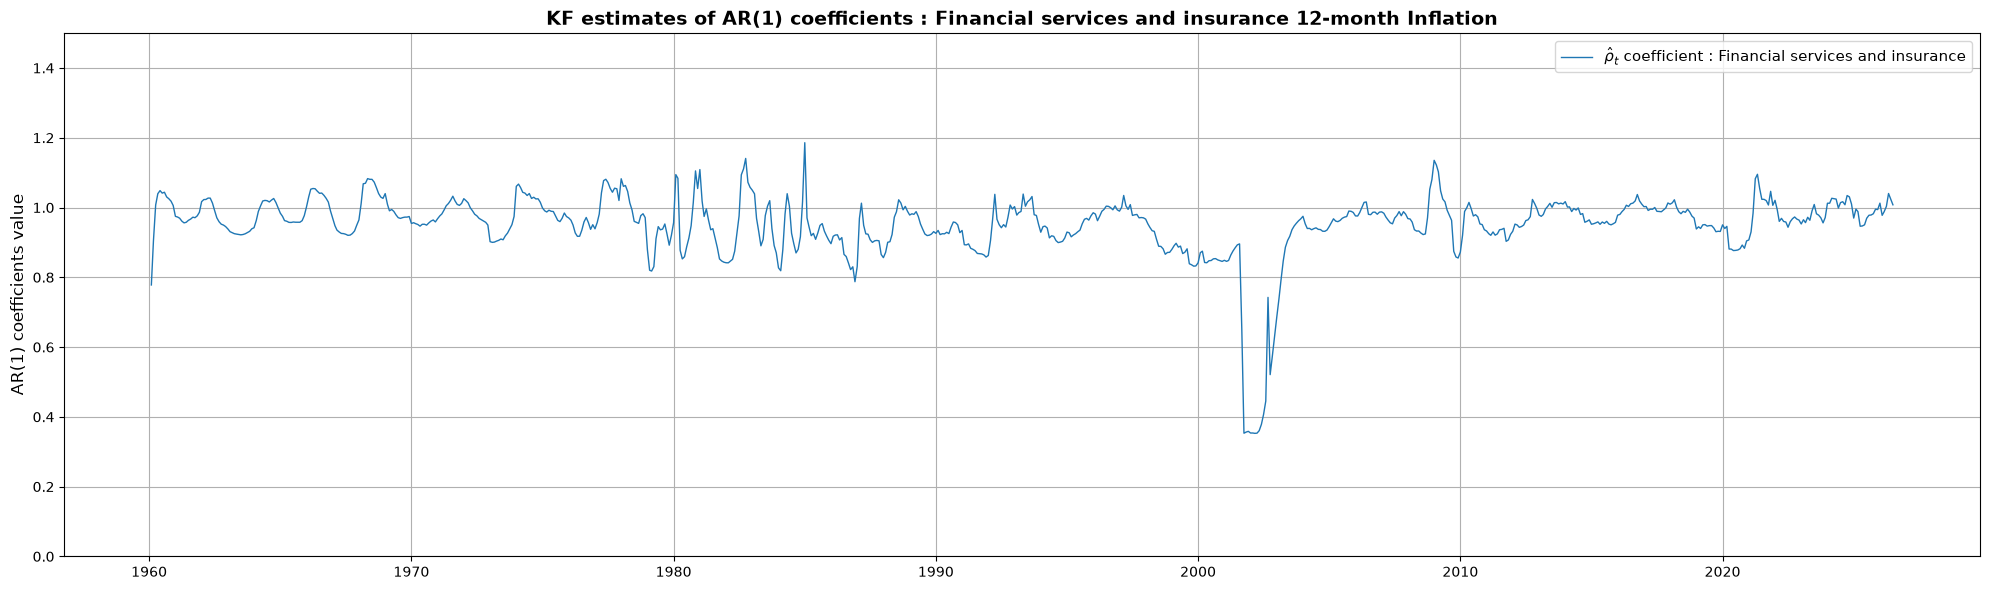

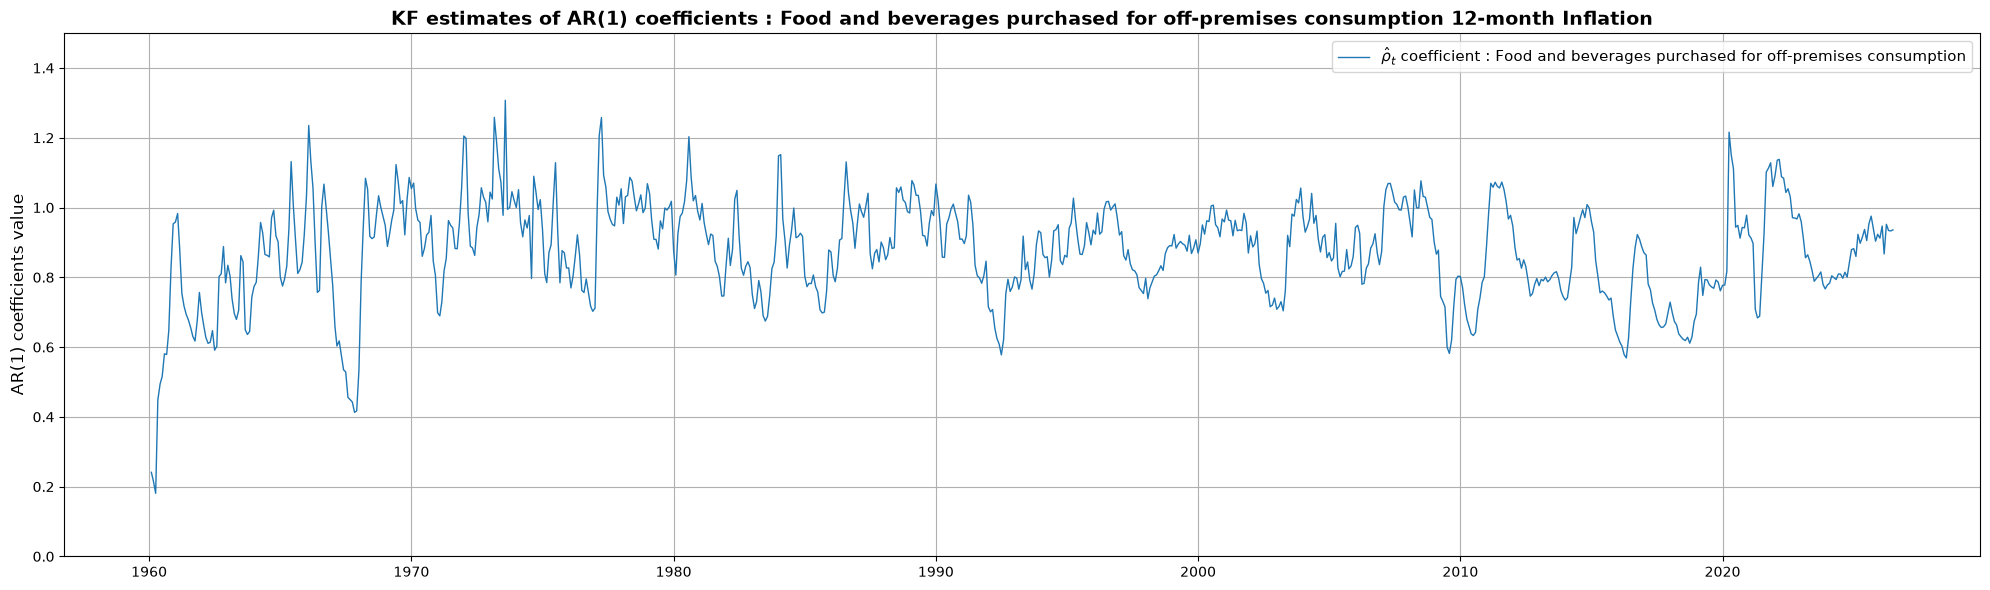

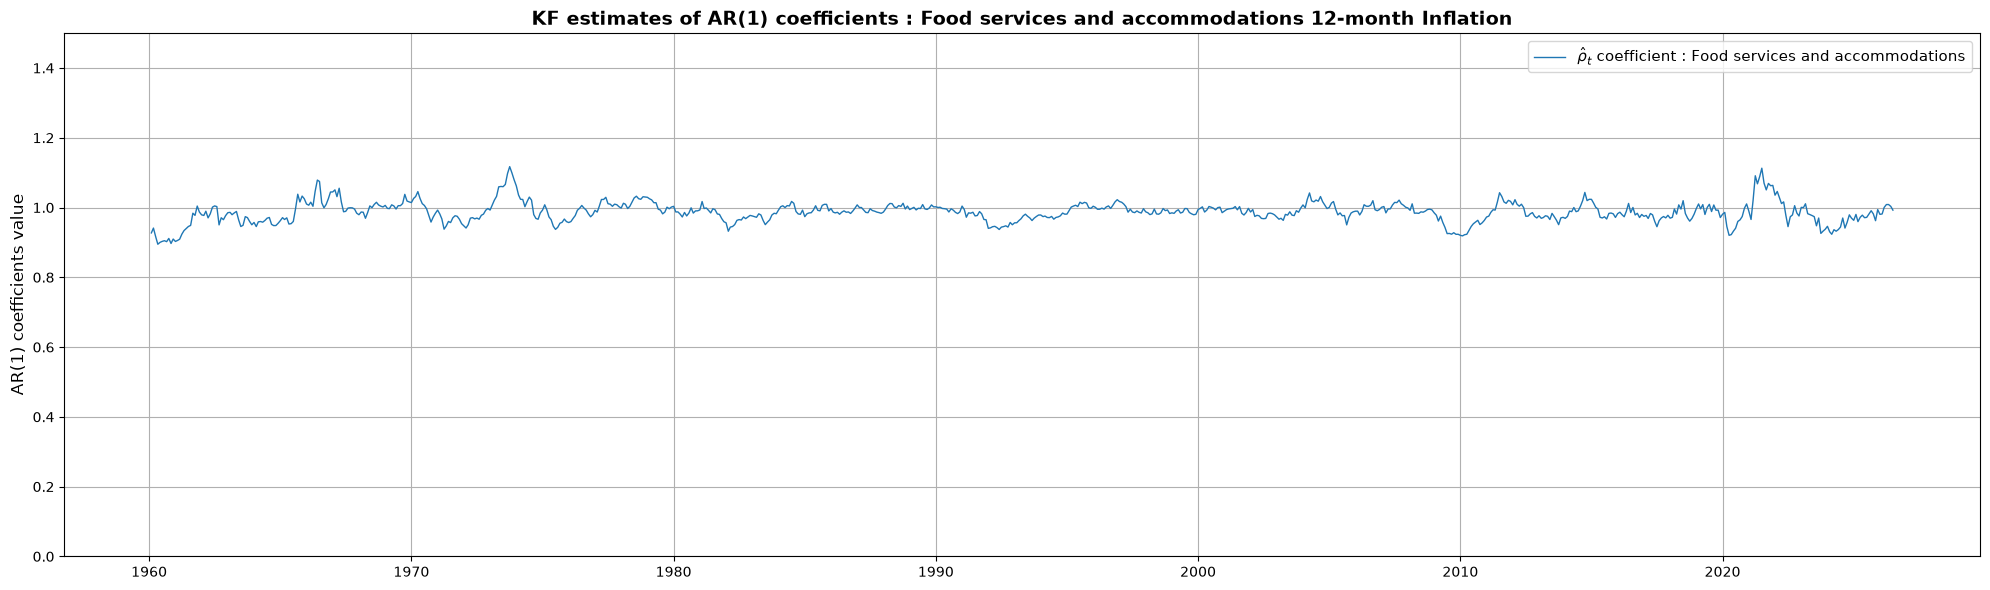

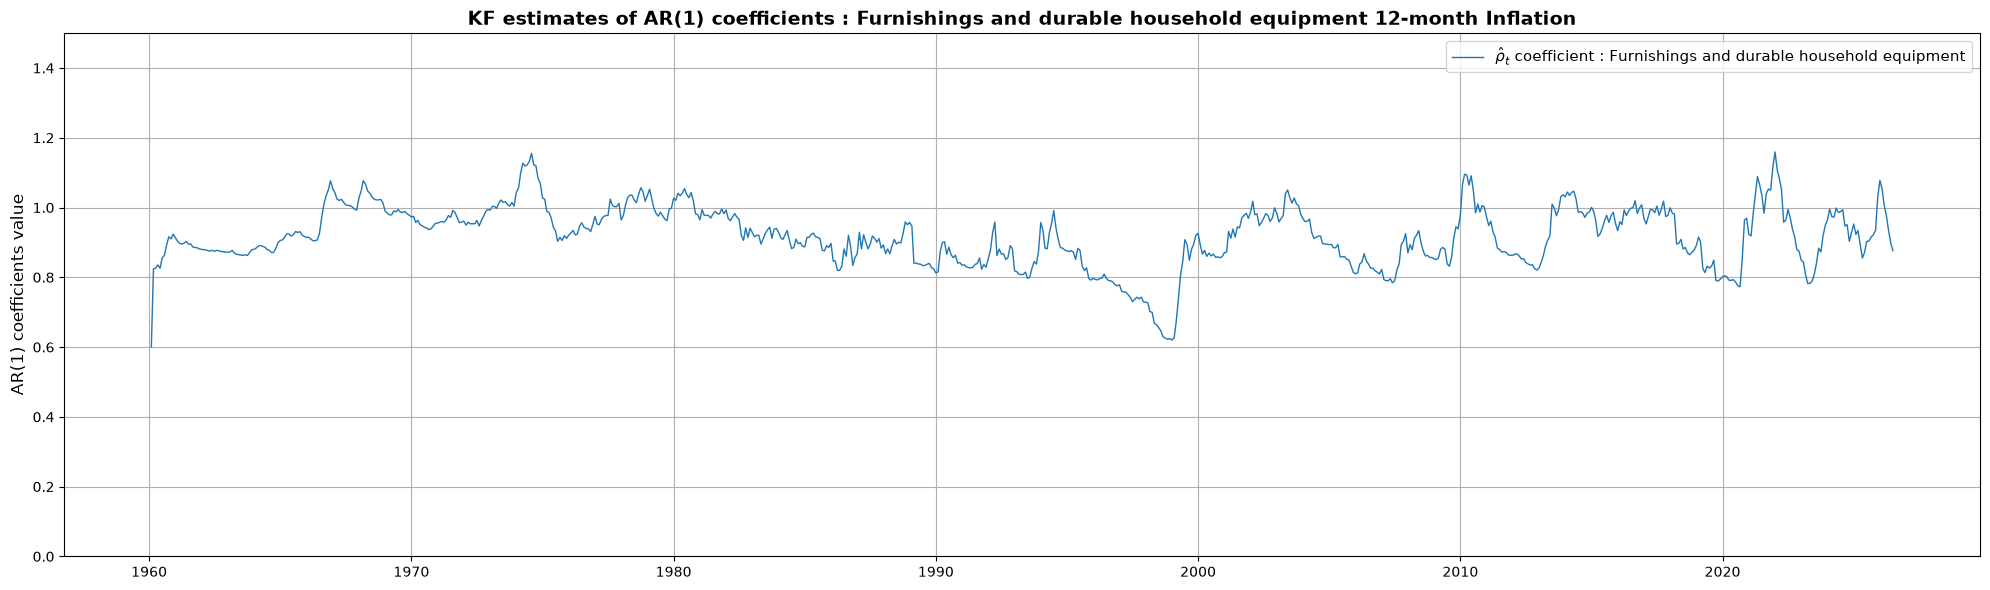

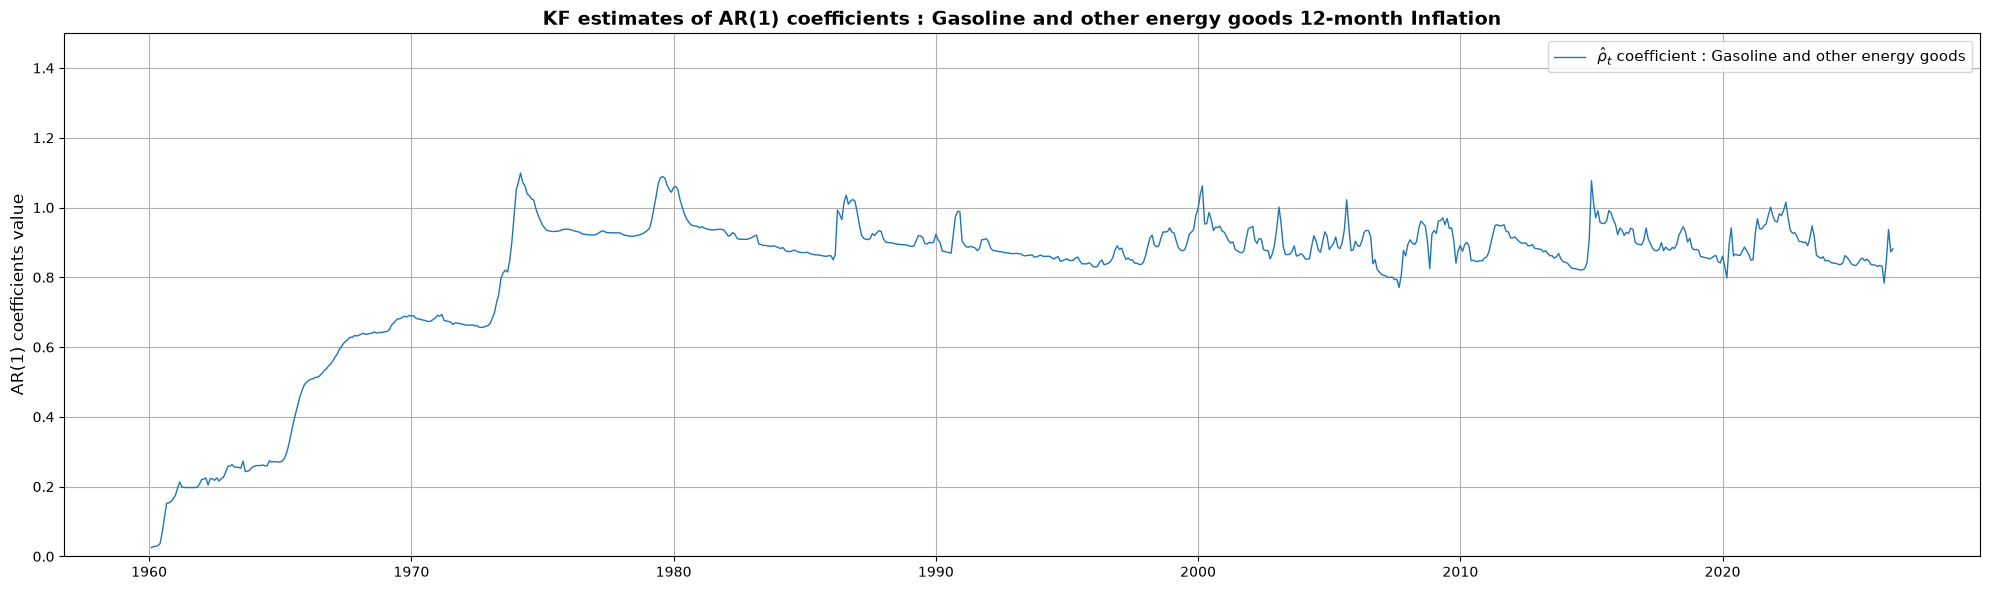

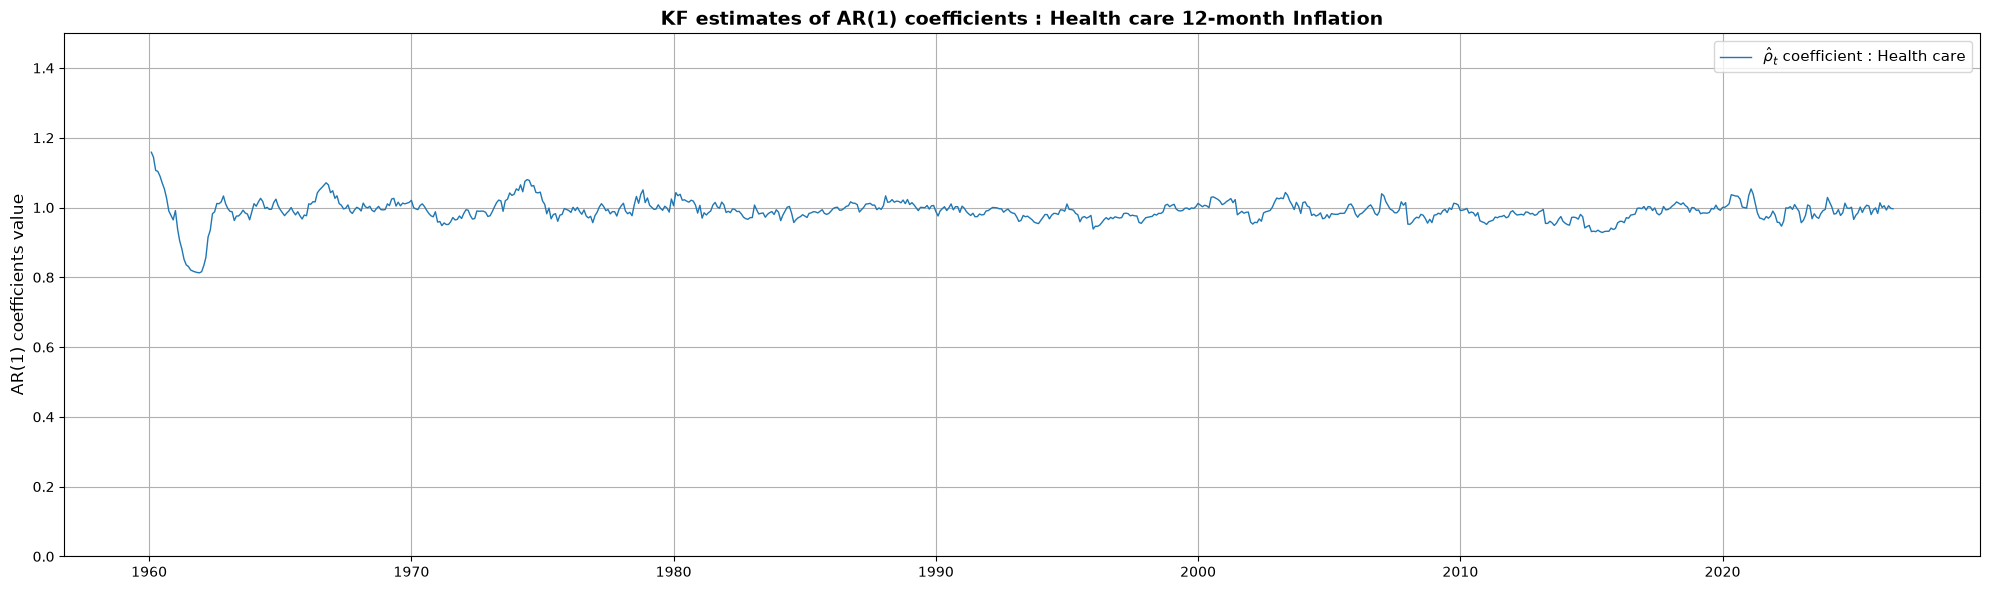

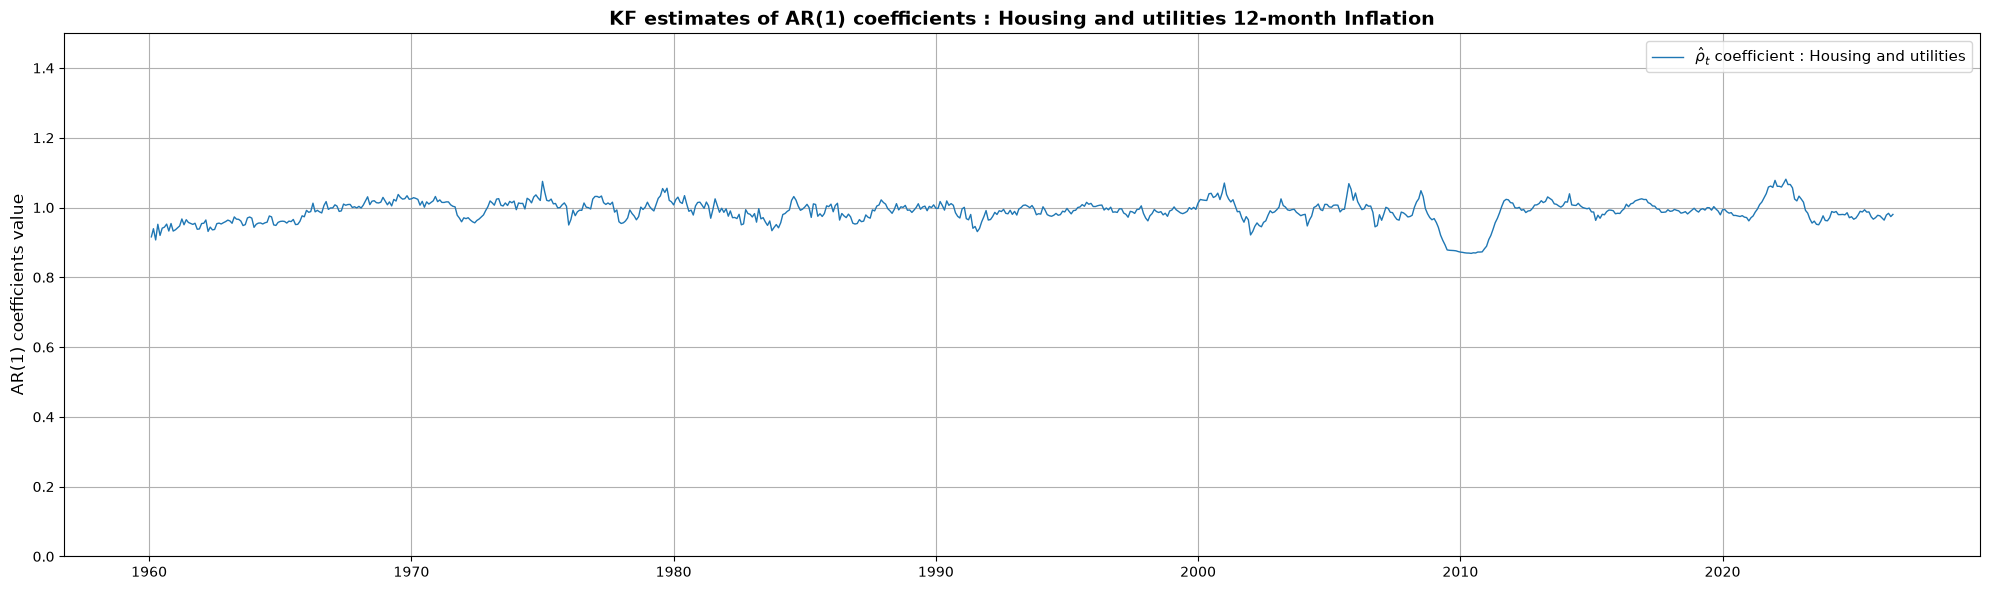

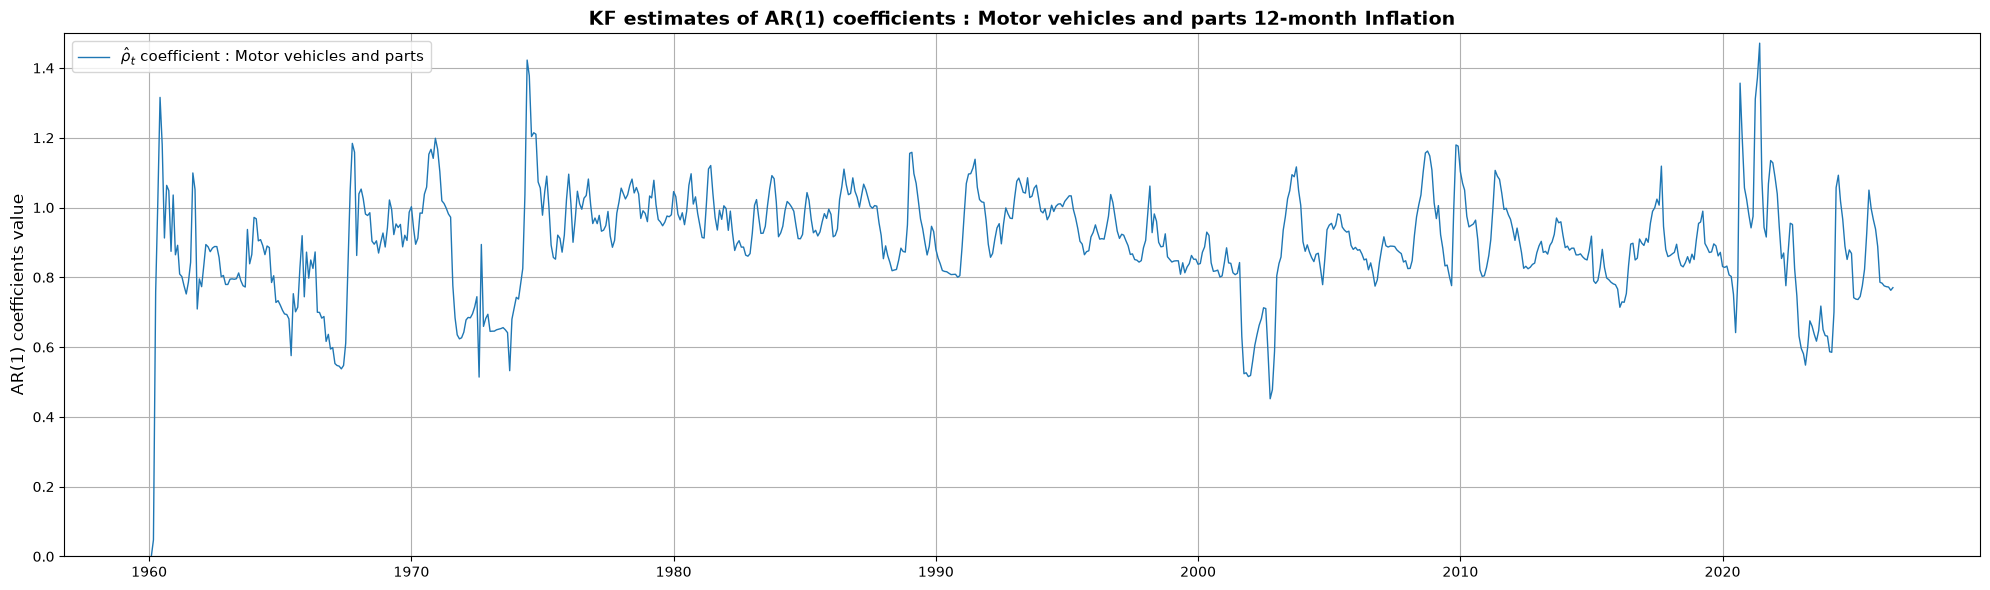

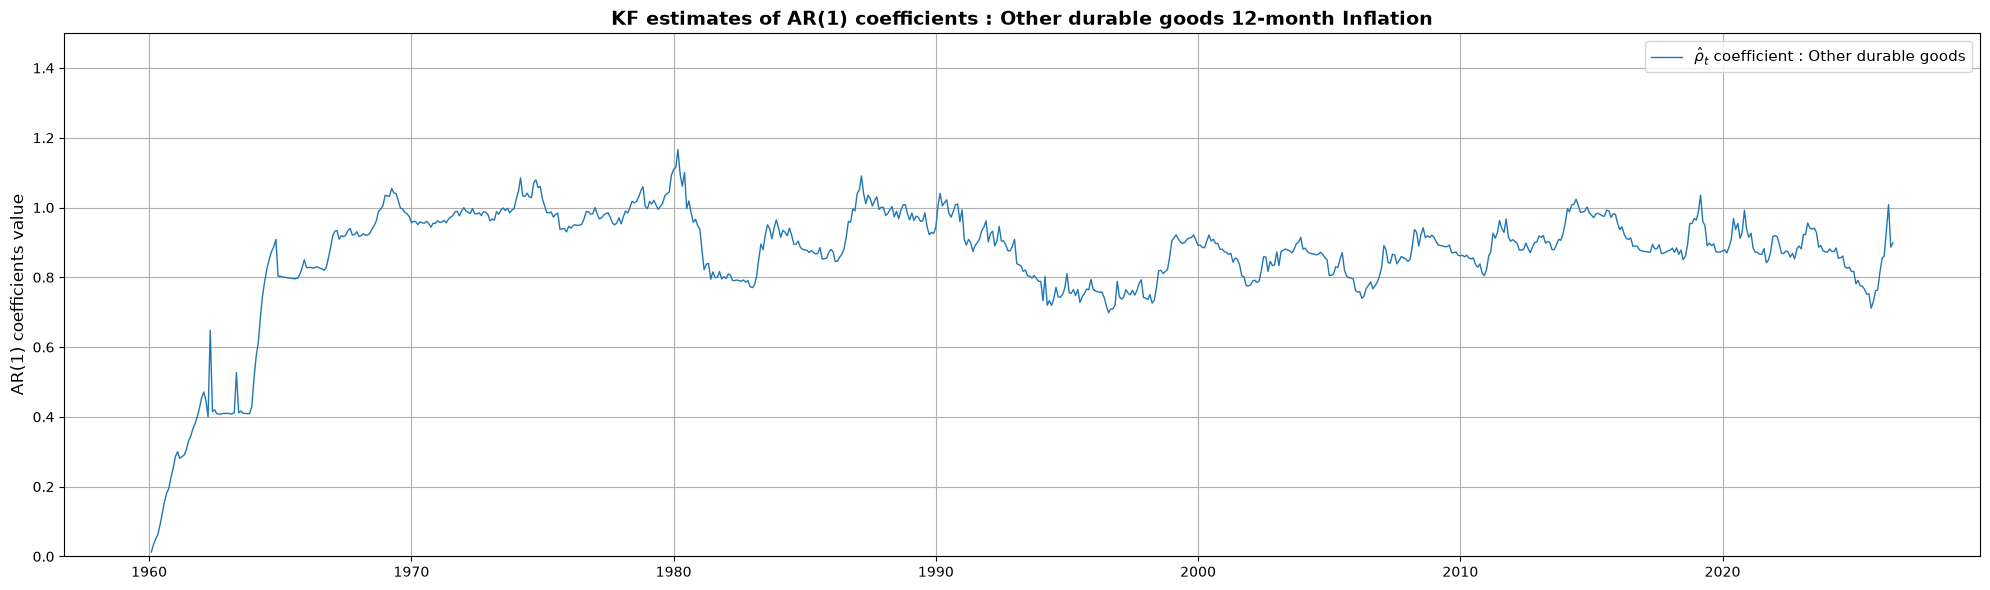

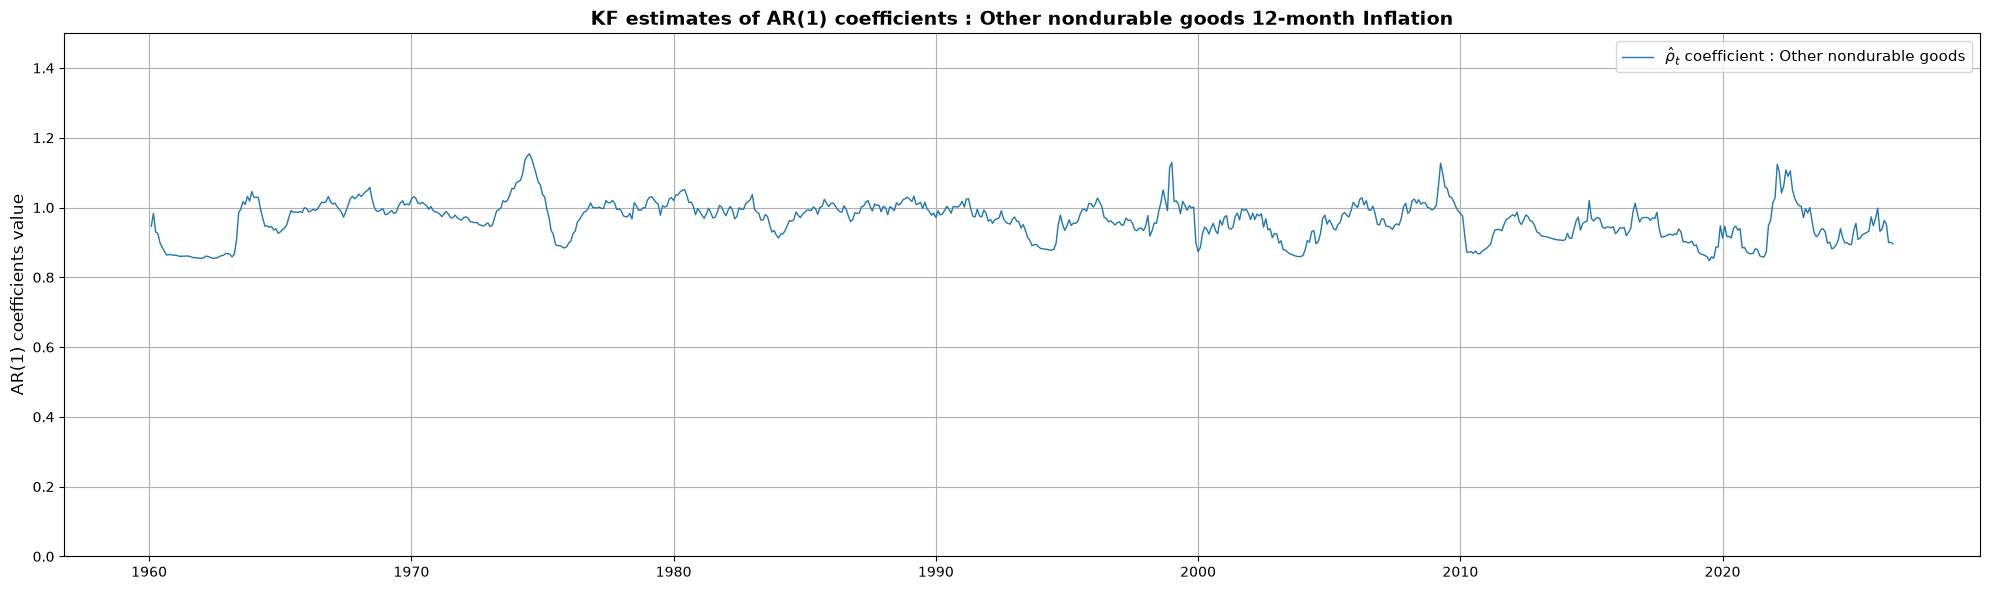

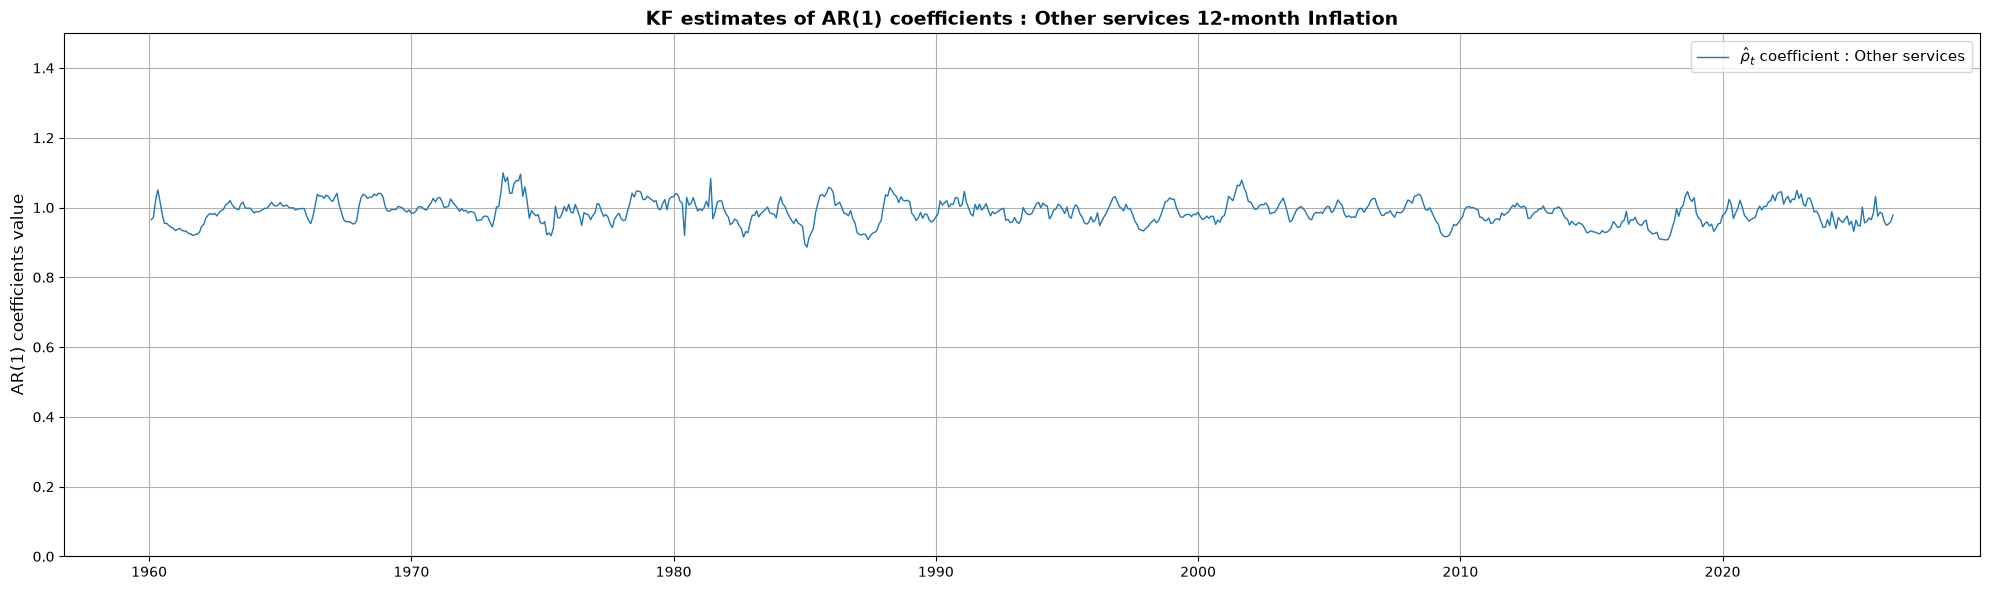

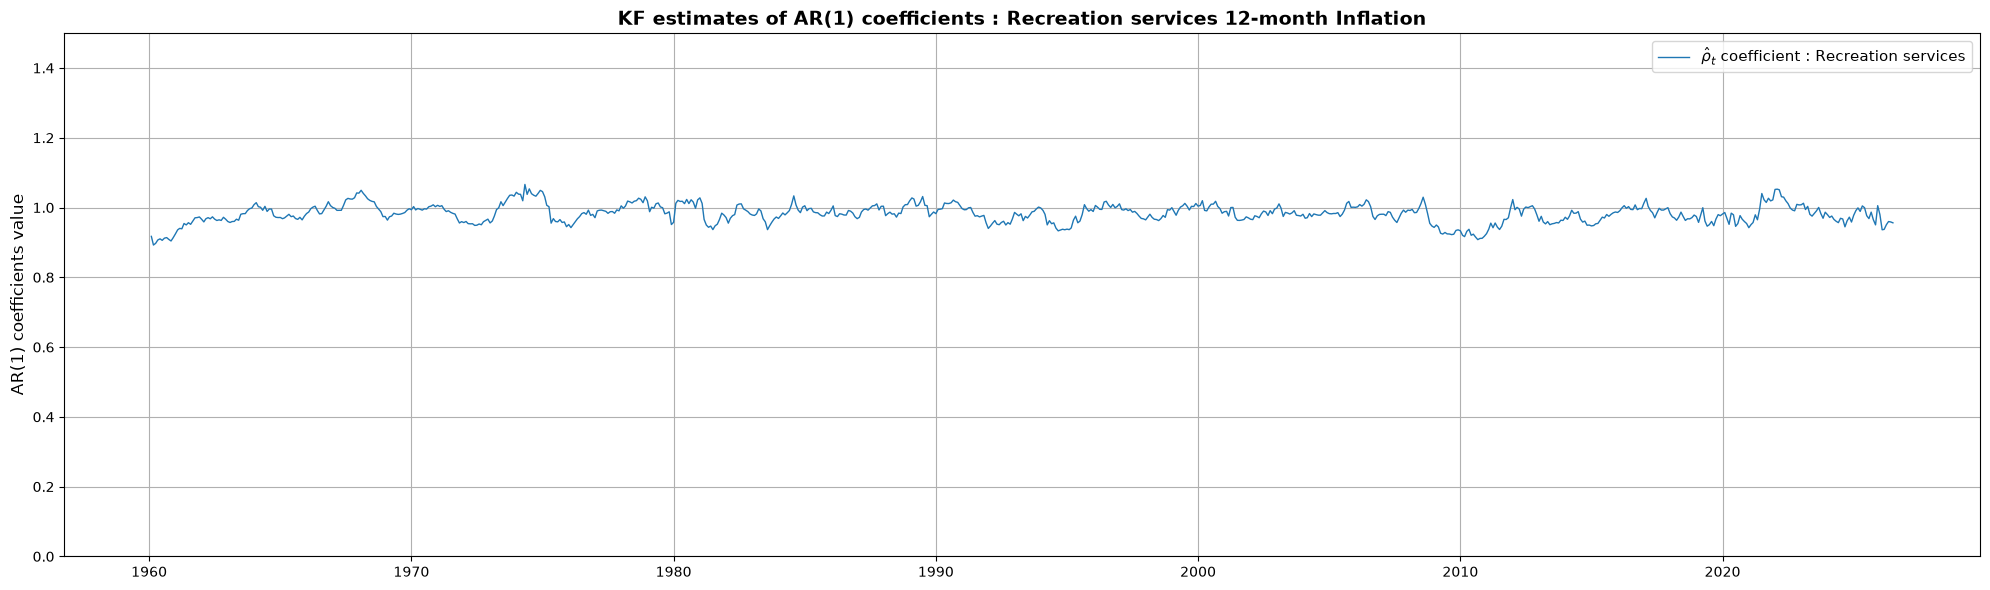

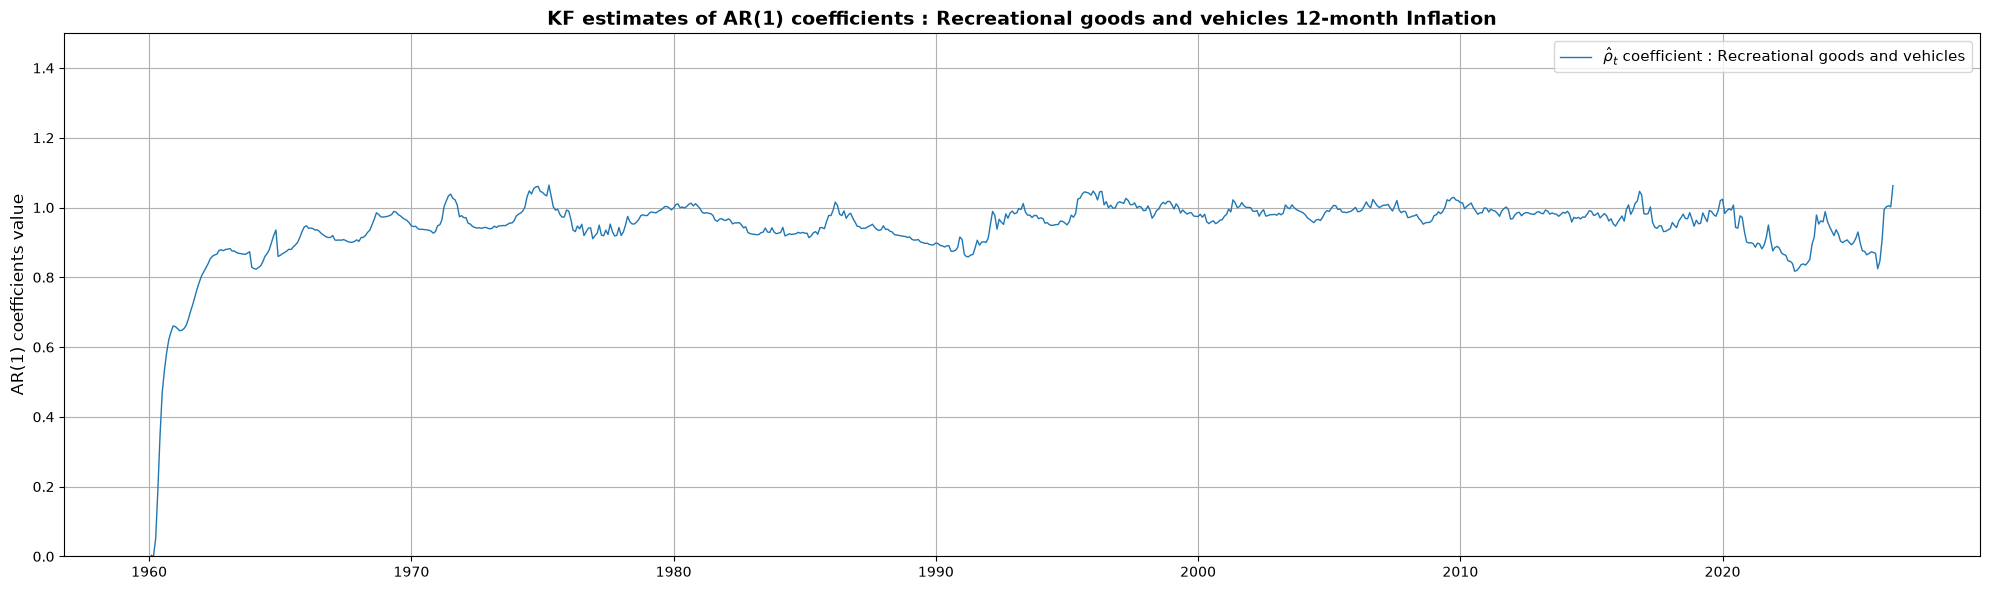

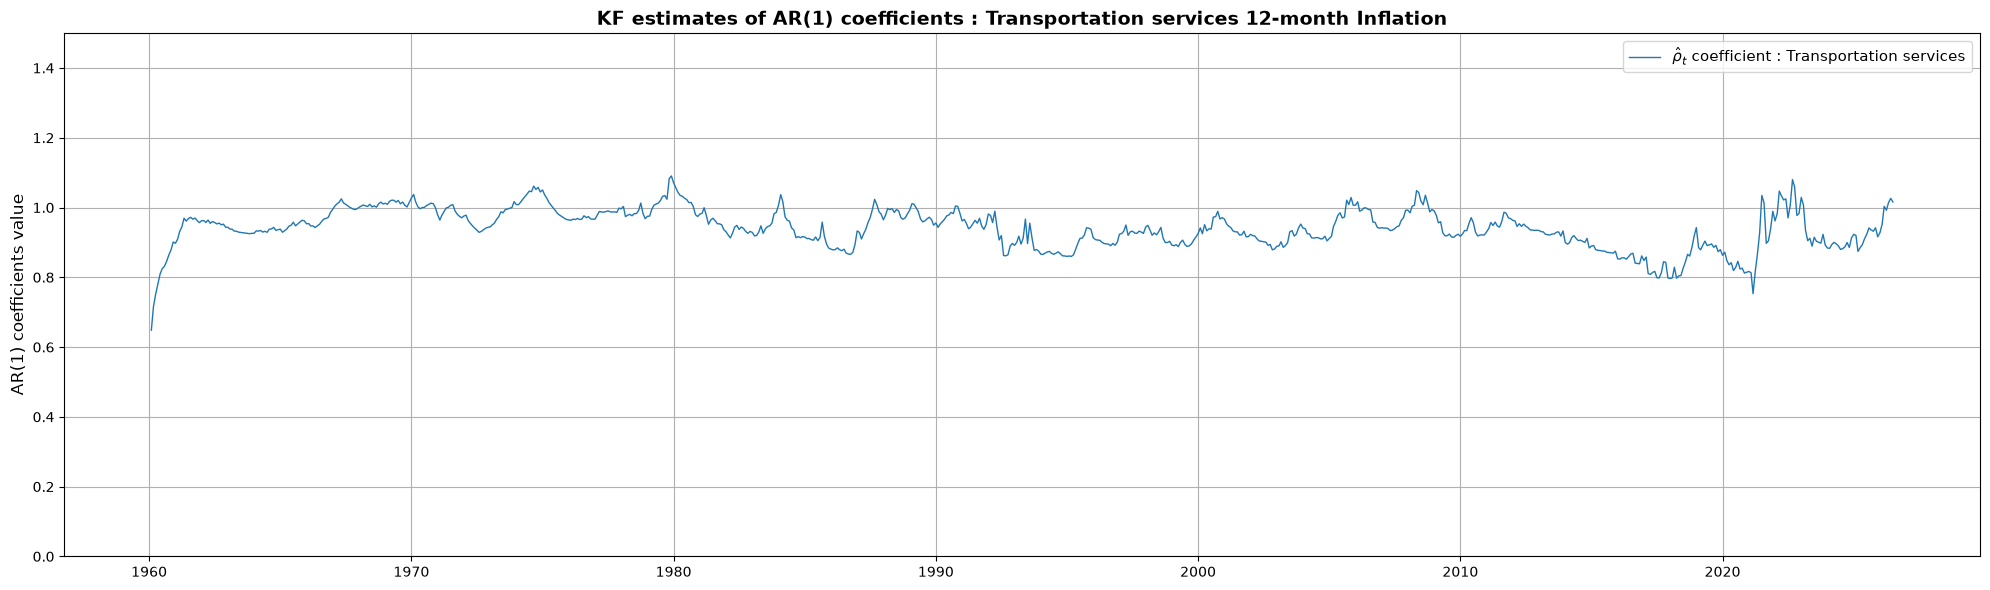

In [12]:
# Etude de la persistance...
for col in dI.columns:
    fig, ax2 = plt.subplots(figsize=(20, 6))
    Rho = allResults[col]["Rho"]
    
    ax2.plot(
        xAxis,
        Rho,
        label=rf'$\hat \rho_t$ coefficient : {col}',
        linewidth=1
    )

    ax2.set_ylabel("AR(1) coefficients value", fontsize=12)
    ax2.tick_params(axis="y")
    ax2.set_ylim(0,1.5)
    # --- Title, legend ---
    plt.title(f"KF estimates of AR(1) coefficients : {col} {lag}-month Inflation", fontsize=14, fontweight="bold")
    plt.legend(loc="best", fontsize=11)
    plt.grid()
    plt.tight_layout()
    plt.show()